In [2]:
import ee
import pandas as pd

ee.Authenticate()
ee.Initialize(project='osmgee')

watersheds = ee.FeatureCollection('projects/osmgee/assets/OSM_Watersheds')
watershed_geom = watersheds.geometry()

ASSET_PROJECT = 'projects/annual-ccdc-new/assets'

FIVE_YEAR_YEARS = list(range(1985, 2026, 5))
print('Years to load:', FIVE_YEAR_YEARS)

Years to load: [1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]


In [3]:
# ============================================
# NEW: Load the 7-class ABMI photoplot training source
# ============================================

training_source = ee.FeatureCollection(
    'projects/annual-ccdc-new/assets/OSMWetland/ABMI_PhotoPlots_Clipped_Watershed'
)

print('Feature count:', training_source.size().getInfo())
print('Properties of first feature:', training_source.first().propertyNames().getInfo())

Feature count: 442
Properties of first feature: ['UHEIGHT', 'NV_PER', 'UORIGIN_YR', 'MOD3_PER', 'INFRA_TY', 'SP4_PER', 'WTLD_TY', 'HYDR_REG', 'DENSITY', 'LU1_LEVEL1', 'MyClass', 'LU1_LEVEL2', 'LU2_LEVEL2', 'STATUS', 'MPT_CNT', 'LU2_LEVEL1', 'SP3_PER', 'NV_TYPE', 'MOIST_REG', 'LC2', 'LC1', 'NWOOD_PER', 'LC3', 'AREA_NET', 'USP5', 'USP4', 'SP2_PER', 'USP3', 'GAWL_TY', 'USP2', 'INFRA_CL', 'MOD1', 'MOD1_YR', 'NUTR_REG', 'WAWL_TY', 'USITE_HT', 'MOD2', 'SP1_PER', 'USP4_PER', 'MOD3', 'NV_CLASS', 'USP5_PER', 'STAND_STRU', 'MOD2_YR', 'UDENSITY', 'NTW_TY', 'ORIGIN', 'SEC_HT', 'USP1', 'USP3_PER', 'NTW_HT', 'WAUL_TY', 'SOIL_TY', 'QC_ATTR3B', 'UORIGIN', 'OBS', 'MOD1_PER', 'MOD3_YR', 'ORIGIN_YR', 'USP2_PER', 'ABMI_SITE', 'NWOOD_TY', 'HEIGHT', 'Shape_Leng', 'SITE_HT', 'MOD2_PER', 'SP2', 'SP1', 'SP4', 'SP5_PER', 'USP1_PER', 'SP3', 'PER_POLY', 'Shape_Area', 'SP5', 'POLYGON_ID', 'WetlandTyp', 'NTW_PER', 'system:index']


In [4]:
# ============================================
# STEP 2: Confirm the 7-class distribution in WetlandTyp
# ============================================

print('WetlandTyp values:', training_source.aggregate_array('WetlandTyp').distinct().getInfo())
print('Class distribution:', training_source.aggregate_histogram('WetlandTyp').getInfo())

WetlandTyp values: ['Fen', 'Marsh', 'Shrub', 'Open water', 'Swamp', 'Forest', 'Bog']
Class distribution: {'Bog': 12, 'Fen': 96, 'Forest': 274, 'Marsh': 3, 'Open water': 5, 'Shrub': 10, 'Swamp': 42}


In [5]:
# ============================================
# STEP 3: Check polygon area distribution, all 7 classes
# ============================================

areas_and_classes = training_source.reduceColumns(
    reducer=ee.Reducer.toList(2),
    selectors=['Shape_Area', 'WetlandTyp']
).get('list').getInfo()

df_areas = pd.DataFrame(areas_and_classes, columns=['Shape_Area', 'WetlandTyp'])

print(df_areas.groupby('WetlandTyp')['Shape_Area'].describe())

            count          mean           std           min           25%  \
WetlandTyp                                                                  
Bog          12.0  6.032309e+04  9.946453e+04   4327.378247  18144.230886   
Fen          96.0  1.148211e+05  1.455728e+05    166.111626  26886.505278   
Forest      274.0  9.382584e+04  1.945735e+05    257.197589  19485.006682   
Marsh         3.0  7.422562e+04  1.835396e+04  53581.055572  66989.664462   
Open water    5.0  4.217620e+06  9.395710e+06   6137.805815  11245.566385   
Shrub        10.0  1.581923e+05  2.268301e+05   1333.360301  16014.101852   
Swamp        42.0  6.365377e+04  6.588182e+04   1434.997905  19823.374517   

                     50%            75%           max  
WetlandTyp                                             
Bog         22836.233729   33547.143322  3.507188e+05  
Fen         57623.624512  161347.927721  8.288974e+05  
Forest      45452.960406   86053.451587  2.109552e+06  
Marsh       80398.273353  

In [6]:
GRID_SPACING_M = 150

def grid_points_for_polygon(feature):
    geom = feature.geometry()

    grid_image = ee.Image.pixelCoordinates(ee.Projection('EPSG:32612').atScale(GRID_SPACING_M))

    grid_fc = grid_image.sample(
        region=geom,
        scale=GRID_SPACING_M,
        geometries=True
    )

    grid_fc = grid_fc.map(lambda pt: pt.set({
        'WetlandTyp': feature.get('WetlandTyp'),
        'POLYGON_ID': feature.get('POLYGON_ID')
    }))

    return grid_fc


training_points = training_source.map(grid_points_for_polygon).flatten()

print('Total sample points generated:', training_points.size().getInfo())
print('Class distribution:', training_points.aggregate_histogram('WetlandTyp').getInfo())

Total sample points generated: 2797
Class distribution: {'Bog': 32, 'Fen': 488, 'Forest': 1145, 'Marsh': 11, 'Open water': 932, 'Shrub': 74, 'Swamp': 115}


In [7]:
# ============================================
# Visualize all 7 classes — export via limit + save to HTML file
# ============================================

import folium

# 6305 exceeds GEE's 5000-element .getInfo() limit, so cap it for this
# visual check (a representative subset is fine for a spatial sanity look)
points_for_viz = training_points.limit(5000)

print('Points being visualized:', points_for_viz.size().getInfo())

watershed_centroid = watershed_geom.centroid(maxError=1).coordinates().getInfo()
map_center = [watershed_centroid[1], watershed_centroid[0]]

m = folium.Map(location=map_center, zoom_start=10, tiles='OpenStreetMap')

watershed_geojson = watershed_geom.getInfo()
folium.GeoJson(
    watershed_geojson,
    name='Watershed boundary',
    style_function=lambda x: {'color': 'black', 'weight': 2, 'fillOpacity': 0}
).add_to(m)

# Distinct color per class
class_colors = {
    'Forest': '#2E7D32',
    'Fen': '#66BB6A',
    'Swamp': '#00897B',
    'Bog': '#8D6E63',
    'Shrub': '#AFB42B',
    'Open water': '#1565C0',
    'Marsh': '#E91E63',  # bright pink — deliberately eye-catching, since this is the sparsest class
}

points_geojson = points_for_viz.getInfo()

for feature in points_geojson['features']:
    coords = feature['geometry']['coordinates']
    cls = feature['properties'].get('WetlandTyp', '')
    color = class_colors.get(cls, '#999999')
    radius = 5 if cls == 'Marsh' else 2  # make Marsh points bigger so they're visible at all
    folium.CircleMarker(
        location=[coords[1], coords[0]],
        radius=radius,
        color=color,
        fill=True,
        fillOpacity=0.8
    ).add_to(m)

folium.LayerControl().add_to(m)

# Save to file (given the earlier notebook-trust issue)
m.save('/content/training_points_7class_map.html')
print('Map saved to /content/training_points_7class_map.html')

Points being visualized: 2797
Map saved to /content/training_points_7class_map.html


In [8]:
# ============================================
# Rebuild LT_COLLECTION from the 5-yearly fitted assets
# (this was defined earlier in the session but needs to be re-run
# since it's not part of the 7-class training-point rebuild)
# ============================================

FIVE_YEAR_YEARS = list(range(1985, 2026, 5))

LT_FEATURES = ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2']

def load_and_rename_year(year):
    asset_id = f'{ASSET_PROJECT}/LT_fitted_{year}'
    orig_bands = [f'LT_{f}_{year}' for f in LT_FEATURES]
    new_bands = LT_FEATURES

    img = (ee.Image(asset_id)
           .select(orig_bands, new_bands)
           .set('year', year)
           .set('system:time_start', ee.Date.fromYMD(year, 6, 1).millis()))
    return img


year_images = [load_and_rename_year(y) for y in FIVE_YEAR_YEARS]

LT_COLLECTION = ee.ImageCollection.fromImages(year_images)

print('Collection size:', LT_COLLECTION.size().getInfo())
print('First image bands:', LT_COLLECTION.first().bandNames().getInfo())

# Add NBR2 (the no-NIR index from earlier)
def add_no_nir_indices(image):
    nbr2 = image.normalizedDifference(['SWIR1', 'SWIR2']).rename('NBR2')
    return image.addBands([nbr2])

LT_COLLECTION = LT_COLLECTION.map(add_no_nir_indices)
LT_FEATURES = LT_FEATURES + ['NBR2']

print('Updated bands:', LT_COLLECTION.first().bandNames().getInfo())

Collection size: 9
First image bands: ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2']
Updated bands: ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2', 'NBR2']


In [9]:
TRAINING_YEAR = 2020

fitted_image = LT_COLLECTION.filter(ee.Filter.eq('year', TRAINING_YEAR)).first()

print('Bands available:', fitted_image.bandNames().getInfo())

sampled_training_data = fitted_image.sampleRegions(
    collection=training_points,
    scale=30,
    tileScale=8,
    geometries=True
)

print('Sampled feature count:', sampled_training_data.size().getInfo())
print('First sampled feature:', sampled_training_data.first().getInfo())

Bands available: ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2', 'NBR2']
Sampled feature count: 2785
First sampled feature: {'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Point', 'coordinates': [-111.39075461320039, 57.333022921683]}, 'id': '00000000000000000002_0_0', 'properties': {'Blue': 0.025748323649168015, 'Green': 0.05359917879104614, 'NBR2': 0.402651309967041, 'POLYGON_ID': 3880005, 'Red': 0.04221566393971443, 'SWIR1': 0.163933664560318, 'SWIR2': 0.06981461495161057, 'WetlandTyp': 'Fen', 'x': 3176.5, 'y': 42363.5}}


In [10]:
# ============================================
# Encode WetlandTyp as numeric (required by smileRandomForest)
# ============================================

CLASS_MAP = {
    'Bog': 0,
    'Fen': 1,
    'Forest': 2,
    'Marsh': 3,
    'Open water': 4,
    'Shrub': 5,
    'Swamp': 6
}

def encode_class(feature):
    wetland_type = feature.get('WetlandTyp')
    class_num = ee.Algorithms.If(
        ee.String(wetland_type).equals('Bog'), 0,
        ee.Algorithms.If(ee.String(wetland_type).equals('Fen'), 1,
        ee.Algorithms.If(ee.String(wetland_type).equals('Forest'), 2,
        ee.Algorithms.If(ee.String(wetland_type).equals('Marsh'), 3,
        ee.Algorithms.If(ee.String(wetland_type).equals('Open water'), 4,
        ee.Algorithms.If(ee.String(wetland_type).equals('Shrub'), 5,
        ee.Algorithms.If(ee.String(wetland_type).equals('Swamp'), 6, -1)))))))
    return feature.set('WetlandTyp_num', class_num)

sampled_training_data_encoded = sampled_training_data.map(encode_class)

print('Encoded class distribution:', sampled_training_data_encoded.aggregate_histogram('WetlandTyp_num').getInfo())

Encoded class distribution: {'0': 32, '1': 488, '2': 1145, '3': 11, '4': 920, '5': 74, '6': 115}


In [11]:
# ============================================
# Pull sampled 7-class training data into pandas
# ============================================

import pandas as pd

sampled_list = sampled_training_data_encoded.getInfo()['features']

rows = []
for f in sampled_list:
    props = f['properties']
    rows.append(props)

df = pd.DataFrame(rows)

print(df.shape)
print(df['WetlandTyp'].value_counts())

(2785, 11)
WetlandTyp
Forest        1145
Open water     920
Fen            488
Swamp          115
Shrub           74
Bog             32
Marsh           11
Name: count, dtype: int64


In [12]:
# ============================================
# Train scikit-learn Random Forest, 7 classes
# ============================================

from sklearn.ensemble import RandomForestClassifier

FEATURE_BANDS = ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2', 'NBR2']

X = df[FEATURE_BANDS]
y = df['WetlandTyp']

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X, y)

print('Model trained on', len(df), 'samples.')
print('Classes:', rf_model.classes_)

Model trained on 2785 samples.
Classes: ['Bog' 'Fen' 'Forest' 'Marsh' 'Open water' 'Shrub' 'Swamp']


In [13]:
importances = pd.DataFrame({
    'feature': FEATURE_BANDS,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.to_string(index=False))

feature  importance
  SWIR1    0.212852
  SWIR2    0.208694
  Green    0.175651
   Blue    0.146060
    Red    0.129807
   NBR2    0.126935


In [34]:
# ============================================
# Fallback: export composites via batch task instead of direct download
# ============================================

export_tasks_composites = []

for year in ALL_YEARS_7CLASS:
    year_image = LT_COLLECTION.filter(ee.Filter.eq('year', year)).first()
    year_bands = year_image.select(FEATURE_BANDS).clip(watershed_geom)

    task = ee.batch.Export.image.toDrive(
        image=year_bands,
        description=f'composite_7class_{year}',
        folder='GEE_exports_7class_composites',
        fileNamePrefix=f'composite_7class_{year}',
        region=watershed_geom,
        scale=30,
        crs='EPSG:32612',
        maxPixels=1e13,
        fileFormat='GeoTIFF'
    )
    task.start()
    export_tasks_composites.append((year, task))
    print(f'{year}: export started, task ID: {task.id}')

1985: export started, task ID: AA56OOCAFGKP4HZC5SN44RRZ
1990: export started, task ID: TJQYPS5ETBEYRKY6ODYOENF4
1995: export started, task ID: 6QWQKEO72B7JDVTHLCJ4V5IL
2000: export started, task ID: PQKB4EFBGA32RDHW4KWNUF32
2005: export started, task ID: AIZOR6V6CFKQSSXHR5AJGT4C
2010: export started, task ID: 2SI4RJC265VZWIKSVI2WLOJA
2015: export started, task ID: ASS5YFZ6SPMH7IAXEQ6D3FBR
2020: export started, task ID: FQCLKPT3MXG75WFI5KG4UNFO
2025: export started, task ID: JWSWCOAY7DNWFUAUG3LFGJII


In [16]:
ALL_YEARS_7CLASS = list(range(1985, 2026, 5))
print(ALL_YEARS_7CLASS)
# ============================================
# Load each downloaded composite and classify it locally
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import rasterio
import os

os.makedirs('/content/drive/MyDrive/GEE_exports_7class', exist_ok=True)

CLASS_LIST = list(rf_model.classes_)
class_to_int = {c: i for i, c in enumerate(CLASS_LIST)}
print('Class encoding:', class_to_int)

classified_arrays_7class = {}
profiles_7class = {}

for year in ALL_YEARS_7CLASS:
    composite_path = f'/content/drive/MyDrive/GEE_exports_7class_composites/composite_7class_{year}.tif'

    with rasterio.open(composite_path) as src:
        image_array = src.read()
        profile = src.profile.copy()

    n_bands, height, width = image_array.shape
    pixels_flat = image_array.reshape(n_bands, -1).T

    valid_mask = np.isfinite(pixels_flat).all(axis=1)

    predictions_flat = np.full(pixels_flat.shape[0], -1, dtype=np.int8)
    valid_pixels = pixels_flat[valid_mask]

    if valid_pixels.shape[0] > 0:
        predicted_classes = rf_model.predict(valid_pixels)
        predicted_int = np.array([class_to_int[c] for c in predicted_classes], dtype=np.int8)
        predictions_flat[valid_mask] = predicted_int

    classified_raster = predictions_flat.reshape(height, width)
    classified_arrays_7class[year] = classified_raster
    profiles_7class[year] = profile

    output_profile = profile.copy()
    output_profile.update(count=1, dtype='int8', nodata=-1)
    output_path = f'/content/drive/MyDrive/GEE_exports_7class/classified_7class_{year}.tif'

    with rasterio.open(output_path, 'w', **output_profile) as dst:
        dst.write(classified_raster, 1)

    print(f'{year}: classified and saved. Class counts:', np.unique(classified_raster, return_counts=True))

[1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Class encoding: {'Bog': 0, 'Fen': 1, 'Forest': 2, 'Marsh': 3, 'Open water': 4, 'Shrub': 5, 'Swamp': 6}


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


1985: classified and saved. Class counts: (array([-1,  0,  1,  2,  3,  4,  5,  6], dtype=int8), array([32250060,    11577,   482720,  1312564,    11971,   150541,
           3279,    12302]))


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


1990: classified and saved. Class counts: (array([-1,  0,  1,  2,  3,  4,  5,  6], dtype=int8), array([32204069,    14374,   561373,  1242426,    11903,   186946,
           4228,     9695]))


...

2015: classified and saved. Class counts: (array([-1,  0,  1,  2,  3,  4,  5,  6], dtype=int8), array([32186792,    11664,   556299,  1264839,     2464,   183862,
           9365,    19729]))


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


2020: classified and saved. Class counts: (array([-1,  0,  1,  2,  3,  4,  5,  6], dtype=int8), array([32187678,    16889,   604407,  1206441,     2597,   184142,
          13571,    19289]))


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


2025: classified and saved. Class counts: (array([-1,  0,  1,  2,  3,  4,  5,  6], dtype=int8), array([32191015,    15625,   606515,  1199017,     8616,   179637,
          17545,    17044]))


In [17]:
# ============================================
# Build the watershed mask (same fix as the 2-class pipeline)
# ============================================

from rasterio.features import geometry_mask

watershed_utm = watershed_geom.transform('EPSG:32612', maxError=1)
watershed_utm_geojson = watershed_utm.getInfo()

with rasterio.open(f'/content/drive/MyDrive/GEE_exports_7class/classified_7class_{ALL_YEARS_7CLASS[0]}.tif') as src:
    transform = src.transform
    out_shape = (src.height, src.width)

    watershed_mask_7class = geometry_mask(
        [watershed_utm_geojson],
        out_shape=out_shape,
        transform=transform,
        invert=True
    )

print('Valid (inside watershed) pixels:', watershed_mask_7class.sum())

Valid (inside watershed) pixels: 1958621


In [18]:
# ============================================
# Compute totals per year using the corrected mask
# ============================================

CLASS_NAMES_7 = {0: 'Bog', 1: 'Fen', 2: 'Forest', 3: 'Marsh', 4: 'Open water', 5: 'Shrub', 6: 'Swamp'}
n_classes_7 = 7

with rasterio.open(f'/content/drive/MyDrive/GEE_exports_7class/classified_7class_{ALL_YEARS_7CLASS[0]}.tif') as src:
    PIXEL_AREA_KM2_7 = (src.res[0] * src.res[1]) / 1_000_000

totals_7class = np.zeros((len(ALL_YEARS_7CLASS), n_classes_7))

for i, year in enumerate(ALL_YEARS_7CLASS):
    arr = classified_arrays_7class[year]
    for c in range(n_classes_7):
        totals_7class[i, c] = np.sum((arr == c) & watershed_mask_7class) * PIXEL_AREA_KM2_7

print('Totals per year (rows=years, cols=[Bog,Fen,Forest,Marsh,Open water,Shrub,Swamp]):')
print(totals_7class)

Totals per year (rows=years, cols=[Bog,Fen,Forest,Marsh,Open water,Shrub,Swamp]):
[[   9.4752  408.2931 1129.446    10.3617  131.8743    2.844    10.5156]
 [  12.2715  476.5887 1068.3333   10.3347  163.9332    3.6738    8.271 ]
 [   8.5905  482.9265 1058.7744   10.5264  175.5963    4.0671    7.3377]
 [   9.4059  409.7718 1158.1749    3.4686  152.6211    3.942    10.5201]
 [   7.7049  415.6758 1153.7649    3.1707  156.0546    4.5873   12.3057]
 [   7.3089  438.7203 1128.5091    2.7522  160.0686    5.9445   14.7474]
 [   9.7479  467.8911 1092.7584    2.151   161.5068    8.1648   16.5636]
 [  13.8393  509.6502 1042.2117    2.2725  161.7858   11.8611   16.3809]
 [  12.7656  512.3043 1034.6535    7.6563  157.8537   15.2145   14.5431]]


In [20]:
for i, year in enumerate(ALL_YEARS_7CLASS):
    year_total = totals_7class[i].sum()
    print(f'{year}: total={year_total:.1f} km²')
    for c in range(n_classes_7):
        pct = 100 * totals_7class[i, c] / year_total if year_total > 0 else 0
        print(f'   {CLASS_NAMES_7[c]}: {totals_7class[i, c]:.1f} km² ({pct:.1f}%)')
    print()

1985: total=1702.8 km²
   Bog: 9.5 km² (0.6%)
   Fen: 408.3 km² (24.0%)
   Forest: 1129.4 km² (66.3%)
   Marsh: 10.4 km² (0.6%)
   Open water: 131.9 km² (7.7%)
   Shrub: 2.8 km² (0.2%)
   Swamp: 10.5 km² (0.6%)

1990: total=1743.4 km²
   Bog: 12.3 km² (0.7%)
   Fen: 476.6 km² (27.3%)
   Forest: 1068.3 km² (61.3%)
   Marsh: 10.3 km² (0.6%)
   Open water: 163.9 km² (9.4%)
   Shrub: 3.7 km² (0.2%)
   Swamp: 8.3 km² (0.5%)

1995: total=1747.8 km²
   Bog: 8.6 km² (0.5%)
   Fen: 482.9 km² (27.6%)
   Forest: 1058.8 km² (60.6%)
   Marsh: 10.5 km² (0.6%)
   Open water: 175.6 km² (10.0%)
   Shrub: 4.1 km² (0.2%)
   Swamp: 7.3 km² (0.4%)

2000: total=1747.9 km²
   Bog: 9.4 km² (0.5%)
   Fen: 409.8 km² (23.4%)
   Forest: 1158.2 km² (66.3%)
   Marsh: 3.5 km² (0.2%)
   Open water: 152.6 km² (8.7%)
   Shrub: 3.9 km² (0.2%)
   Swamp: 10.5 km² (0.6%)

2005: total=1753.3 km²
   Bog: 7.7 km² (0.4%)
   Fen: 415.7 km² (23.7%)
   Forest: 1153.8 km² (65.8%)
   Marsh: 3.2 km² (0.2%)
   Open water: 156.1 km² (

In [21]:
# ============================================
# 7-class transitions between consecutive years
# ============================================

transitions_7class = []
for i in range(len(ALL_YEARS_7CLASS) - 1):
    arr_a = classified_arrays_7class[ALL_YEARS_7CLASS[i]]
    arr_b = classified_arrays_7class[ALL_YEARS_7CLASS[i + 1]]

    T = np.zeros((n_classes_7, n_classes_7))
    for c_from in range(n_classes_7):
        for c_to in range(n_classes_7):
            T[c_from, c_to] = np.sum((arr_a == c_from) & (arr_b == c_to) & watershed_mask_7class) * PIXEL_AREA_KM2_7
    transitions_7class.append(T)

print('Transitions computed for', len(transitions_7class), 'year-pairs')

Transitions computed for 8 year-pairs


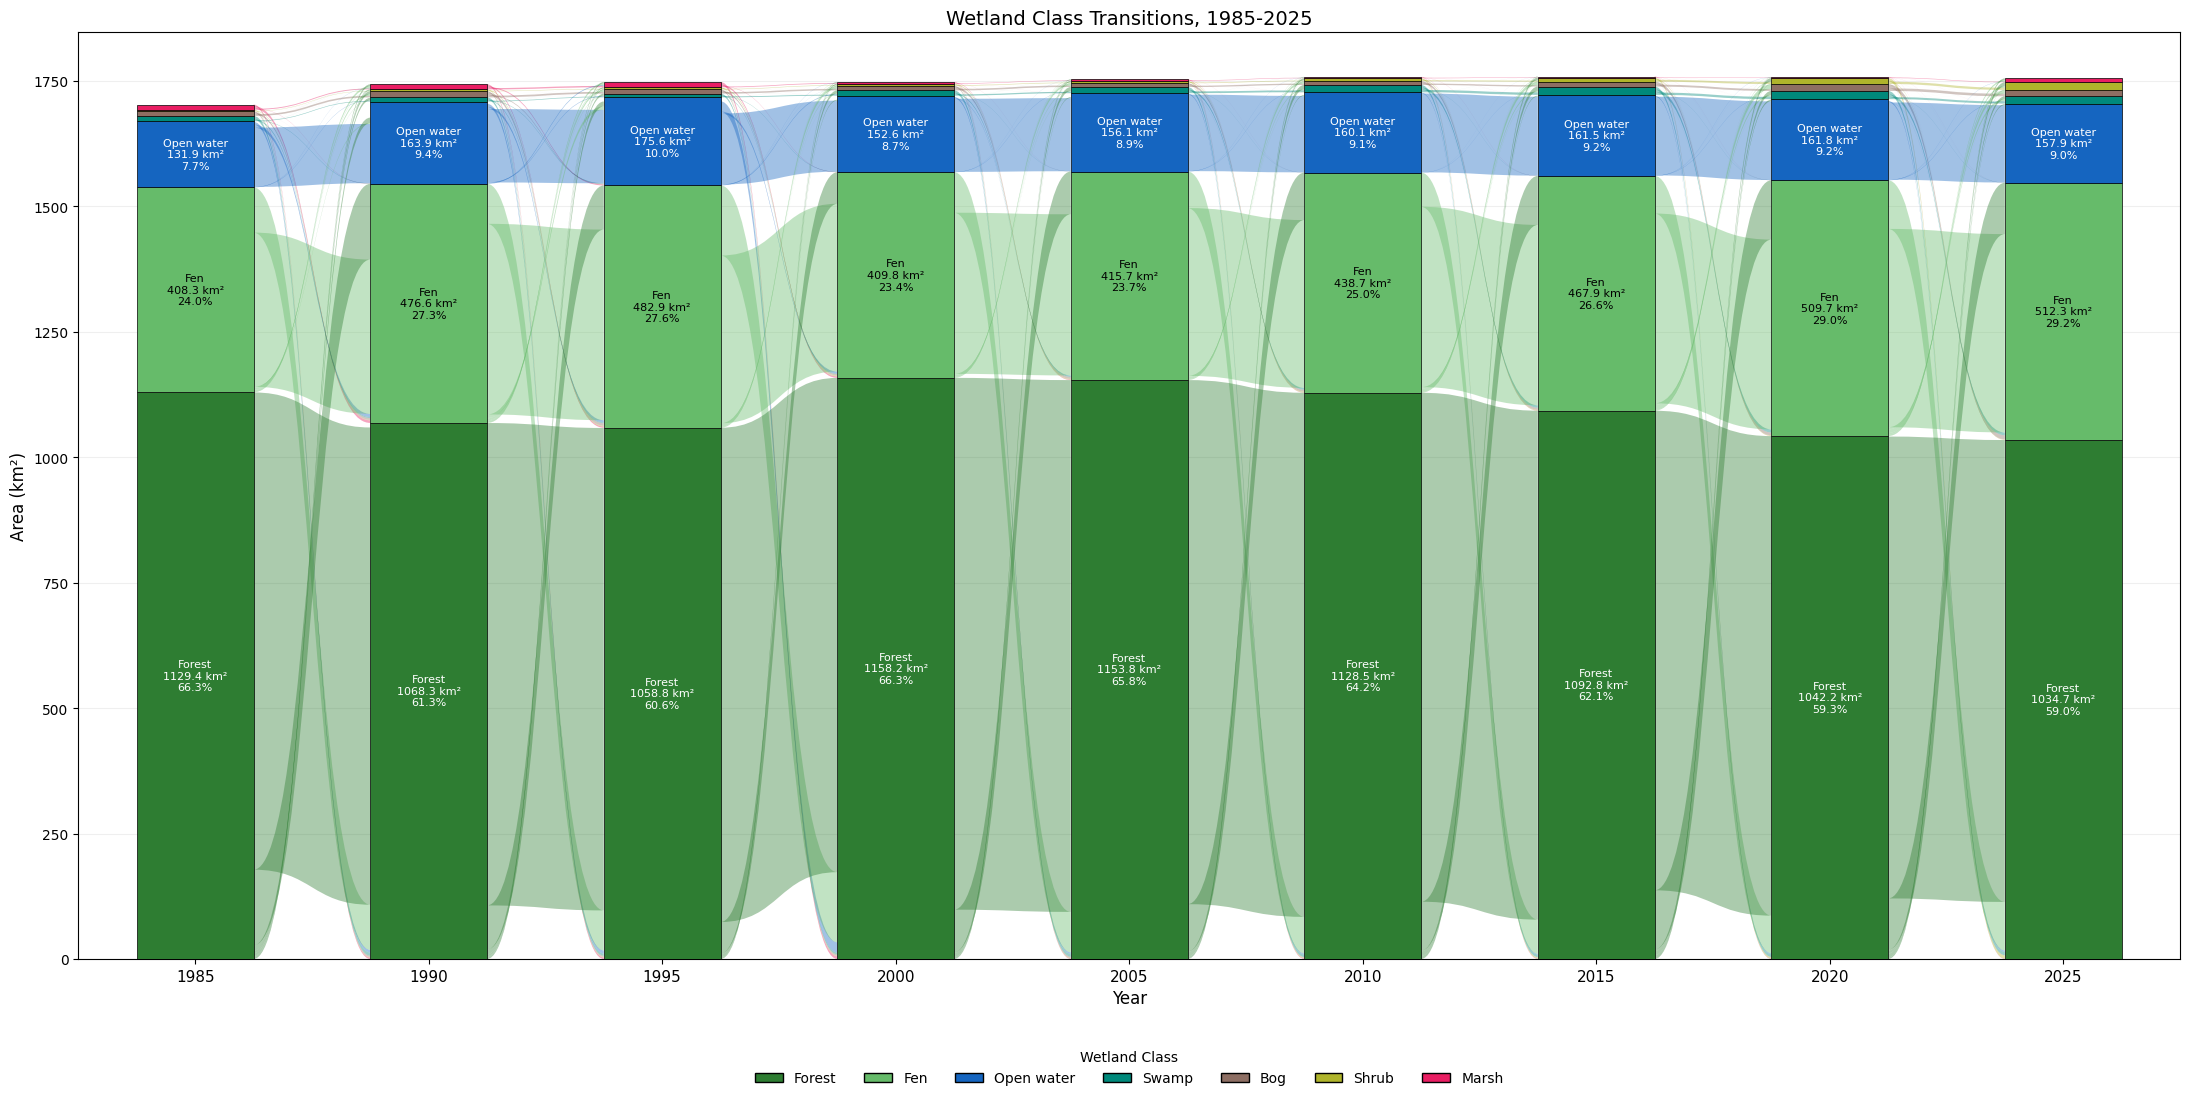

In [22]:
# ============================================
# 7-class alluvial diagram
# ============================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.path import Path
import matplotlib.patches as mpatches

# Colors chosen to be visually distinct and thematically sensible
# (blues for water, greens/browns for vegetated wetland types)
class_colors_7 = {
    0: '#8D6E63',  # Bog - brown
    1: '#66BB6A',  # Fen - medium green
    2: '#2E7D32',  # Forest - dark green
    3: '#E91E63',  # Marsh - pink (kept eye-catching, given how sparse it is)
    4: '#1565C0',  # Open water - blue
    5: '#AFB42B',  # Shrub - olive
    6: '#00897B',  # Swamp - teal
}

fig, ax = plt.subplots(figsize=(22, 11))
bar_width = 0.5
x_positions = np.arange(len(ALL_YEARS_7CLASS))

# Draw order: largest/most stable classes at bottom, smaller ones stacked above
stack_order_7 = [2, 1, 4, 6, 0, 5, 3]  # Forest, Fen, Open water, Swamp, Bog, Shrub, Marsh
stratum_bounds_7 = {}

for i, xc in enumerate(x_positions):
    y_cursor = 0.0
    for c in stack_order_7:
        h = totals_7class[i, c]
        if h > 0:
            ax.add_patch(Rectangle(
                (xc - bar_width / 2, y_cursor), bar_width, h,
                facecolor=class_colors_7[c], edgecolor='black', linewidth=0.5, zorder=3
            ))
            pct = 100 * h / totals_7class[i].sum()
            # Only label segments large enough to read clearly
            if pct > 1.5:
                ax.text(xc, y_cursor + h / 2,
                        f'{CLASS_NAMES_7[c]}\n{h:.1f} km\u00b2\n{pct:.1f}%',
                        ha='center', va='center', fontsize=8, color='white' if c in [2, 4, 6] else 'black',
                        zorder=4)
            stratum_bounds_7[(i, c)] = (y_cursor, y_cursor + h)
        else:
            stratum_bounds_7[(i, c)] = (y_cursor, y_cursor)
        y_cursor += h

for i, T in enumerate(transitions_7class):
    x_a = x_positions[i] + bar_width / 2
    x_b = x_positions[i + 1] - bar_width / 2
    src_cursor = {c: stratum_bounds_7[(i, c)][0] for c in range(n_classes_7)}
    tgt_cursor = {c: stratum_bounds_7[(i + 1, c)][0] for c in range(n_classes_7)}

    for c_from in stack_order_7[::-1]:
        for c_to in stack_order_7[::-1]:
            h = T[c_from, c_to]
            if h <= 0:
                continue
            y0_a = src_cursor[c_from]; y1_a = y0_a + h; src_cursor[c_from] = y1_a
            y0_b = tgt_cursor[c_to]; y1_b = y0_b + h; tgt_cursor[c_to] = y1_b
            xm = (x_a + x_b) / 2
            verts = [(x_a, y0_a), (xm, y0_a), (xm, y0_b), (x_b, y0_b),
                     (x_b, y1_b), (xm, y1_b), (xm, y1_a), (x_a, y1_a), (x_a, y0_a)]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
            ax.add_patch(mpatches.PathPatch(Path(verts, codes),
                         facecolor=class_colors_7[c_from], edgecolor='none', alpha=0.4, zorder=2))

ax.set_xticks(x_positions)
ax.set_xticklabels(ALL_YEARS_7CLASS, fontsize=11)
ax.set_ylabel('Area (km\u00b2)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_title(f'Wetland Class Transitions, {ALL_YEARS_7CLASS[0]}-{ALL_YEARS_7CLASS[-1]}', fontsize=14)
ax.set_ylim(0, totals_7class.sum(axis=1).max() * 1.05)
ax.set_xlim(x_positions[0] - 0.5, x_positions[-1] + 0.5)
ax.grid(axis='y', alpha=0.2, zorder=1)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(facecolor=class_colors_7[c], edgecolor='black', label=CLASS_NAMES_7[c])
                   for c in stack_order_7]
ax.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.15),
          ncol=7, frameon=False, title='Wetland Class')

plt.tight_layout()
plt.savefig('/content/wetland_7class_alluvial.png', dpi=200, bbox_inches='tight')
plt.show()

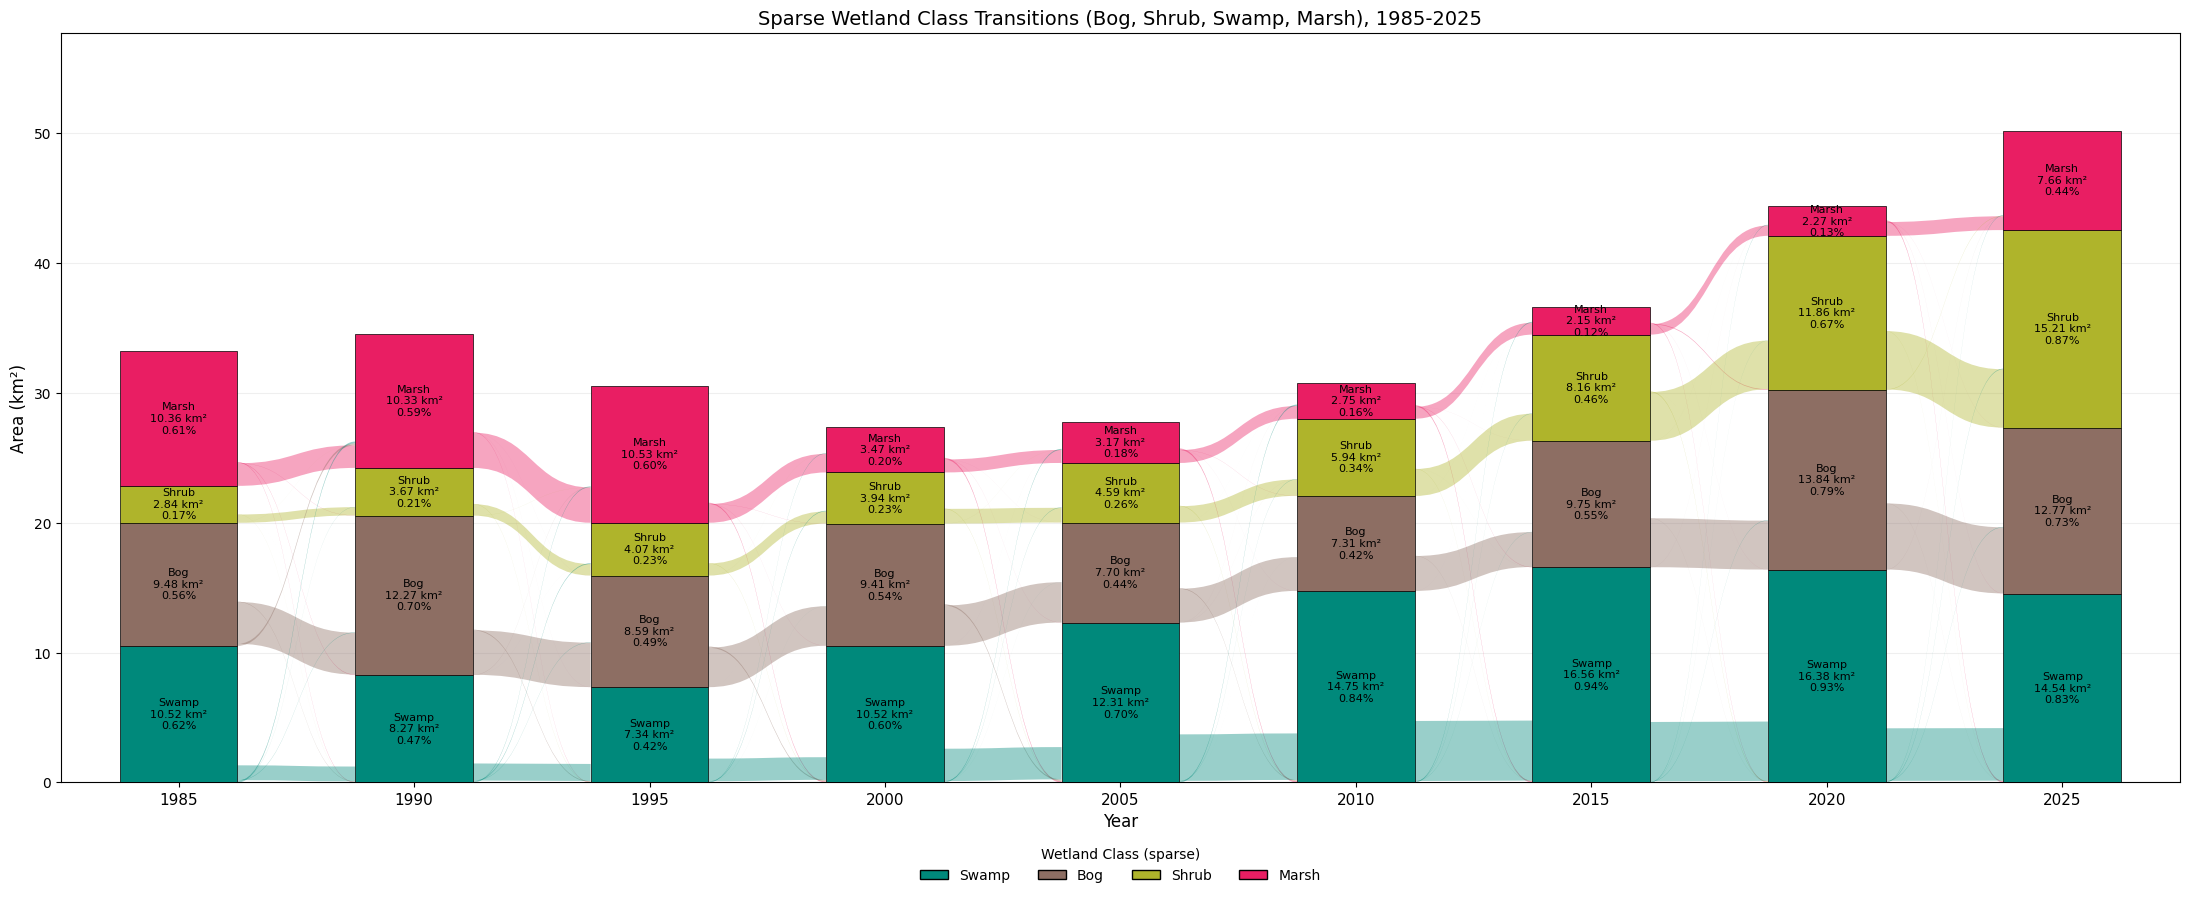

In [23]:
# ============================================
# Companion chart: sparse classes only (Bog, Shrub, Swamp, Marsh)
# Same structure as the main chart, but excluding Forest/Fen/Open water
# so the small classes get their own readable y-axis scale.
# ============================================

sparse_classes = [0, 5, 6, 3]  # Bog, Shrub, Swamp, Marsh

fig2, ax2 = plt.subplots(figsize=(22, 9))

stack_order_sparse = [6, 0, 5, 3]  # Swamp, Bog, Shrub, Marsh (bottom to top)
stratum_bounds_sparse = {}

for i, xc in enumerate(x_positions):
    y_cursor = 0.0
    for c in stack_order_sparse:
        h = totals_7class[i, c]
        if h > 0:
            ax2.add_patch(Rectangle(
                (xc - bar_width / 2, y_cursor), bar_width, h,
                facecolor=class_colors_7[c], edgecolor='black', linewidth=0.5, zorder=3
            ))
            # Compute pct relative to the FULL total, same denominator as
            # the main chart, so the percentages are directly comparable
            pct = 100 * h / totals_7class[i].sum()
            ax2.text(xc, y_cursor + h / 2,
                    f'{CLASS_NAMES_7[c]}\n{h:.2f} km\u00b2\n{pct:.2f}%',
                    ha='center', va='center', fontsize=8, color='black',
                    zorder=4)
            stratum_bounds_sparse[(i, c)] = (y_cursor, y_cursor + h)
        else:
            stratum_bounds_sparse[(i, c)] = (y_cursor, y_cursor)
        y_cursor += h

for i, T in enumerate(transitions_7class):
    x_a = x_positions[i] + bar_width / 2
    x_b = x_positions[i + 1] - bar_width / 2
    src_cursor = {c: stratum_bounds_sparse[(i, c)][0] for c in sparse_classes}
    tgt_cursor = {c: stratum_bounds_sparse[(i + 1, c)][0] for c in sparse_classes}

    for c_from in stack_order_sparse[::-1]:
        for c_to in stack_order_sparse[::-1]:
            h = T[c_from, c_to]
            if h <= 0:
                continue
            y0_a = src_cursor[c_from]; y1_a = y0_a + h; src_cursor[c_from] = y1_a
            y0_b = tgt_cursor[c_to]; y1_b = y0_b + h; tgt_cursor[c_to] = y1_b
            xm = (x_a + x_b) / 2
            verts = [(x_a, y0_a), (xm, y0_a), (xm, y0_b), (x_b, y0_b),
                     (x_b, y1_b), (xm, y1_b), (xm, y1_a), (x_a, y1_a), (x_a, y0_a)]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
            ax2.add_patch(mpatches.PathPatch(Path(verts, codes),
                         facecolor=class_colors_7[c_from], edgecolor='none', alpha=0.4, zorder=2))

ax2.set_xticks(x_positions)
ax2.set_xticklabels(ALL_YEARS_7CLASS, fontsize=11)
ax2.set_ylabel('Area (km\u00b2)', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_title(f'Sparse Wetland Class Transitions (Bog, Shrub, Swamp, Marsh), {ALL_YEARS_7CLASS[0]}-{ALL_YEARS_7CLASS[-1]}', fontsize=14)

sparse_max = max(totals_7class[i, sparse_classes].sum() for i in range(len(ALL_YEARS_7CLASS)))
ax2.set_ylim(0, sparse_max * 1.15)
ax2.set_xlim(x_positions[0] - 0.5, x_positions[-1] + 0.5)
ax2.grid(axis='y', alpha=0.2, zorder=1)
ax2.set_axisbelow(True)

legend_patches_sparse = [mpatches.Patch(facecolor=class_colors_7[c], edgecolor='black', label=CLASS_NAMES_7[c])
                          for c in stack_order_sparse]
ax2.legend(handles=legend_patches_sparse, loc='lower center', bbox_to_anchor=(0.5, -0.15),
           ncol=4, frameon=False, title='Wetland Class (sparse)')

plt.tight_layout()
plt.savefig('/content/wetland_sparse_classes_alluvial.png', dpi=200, bbox_inches='tight')
plt.show()

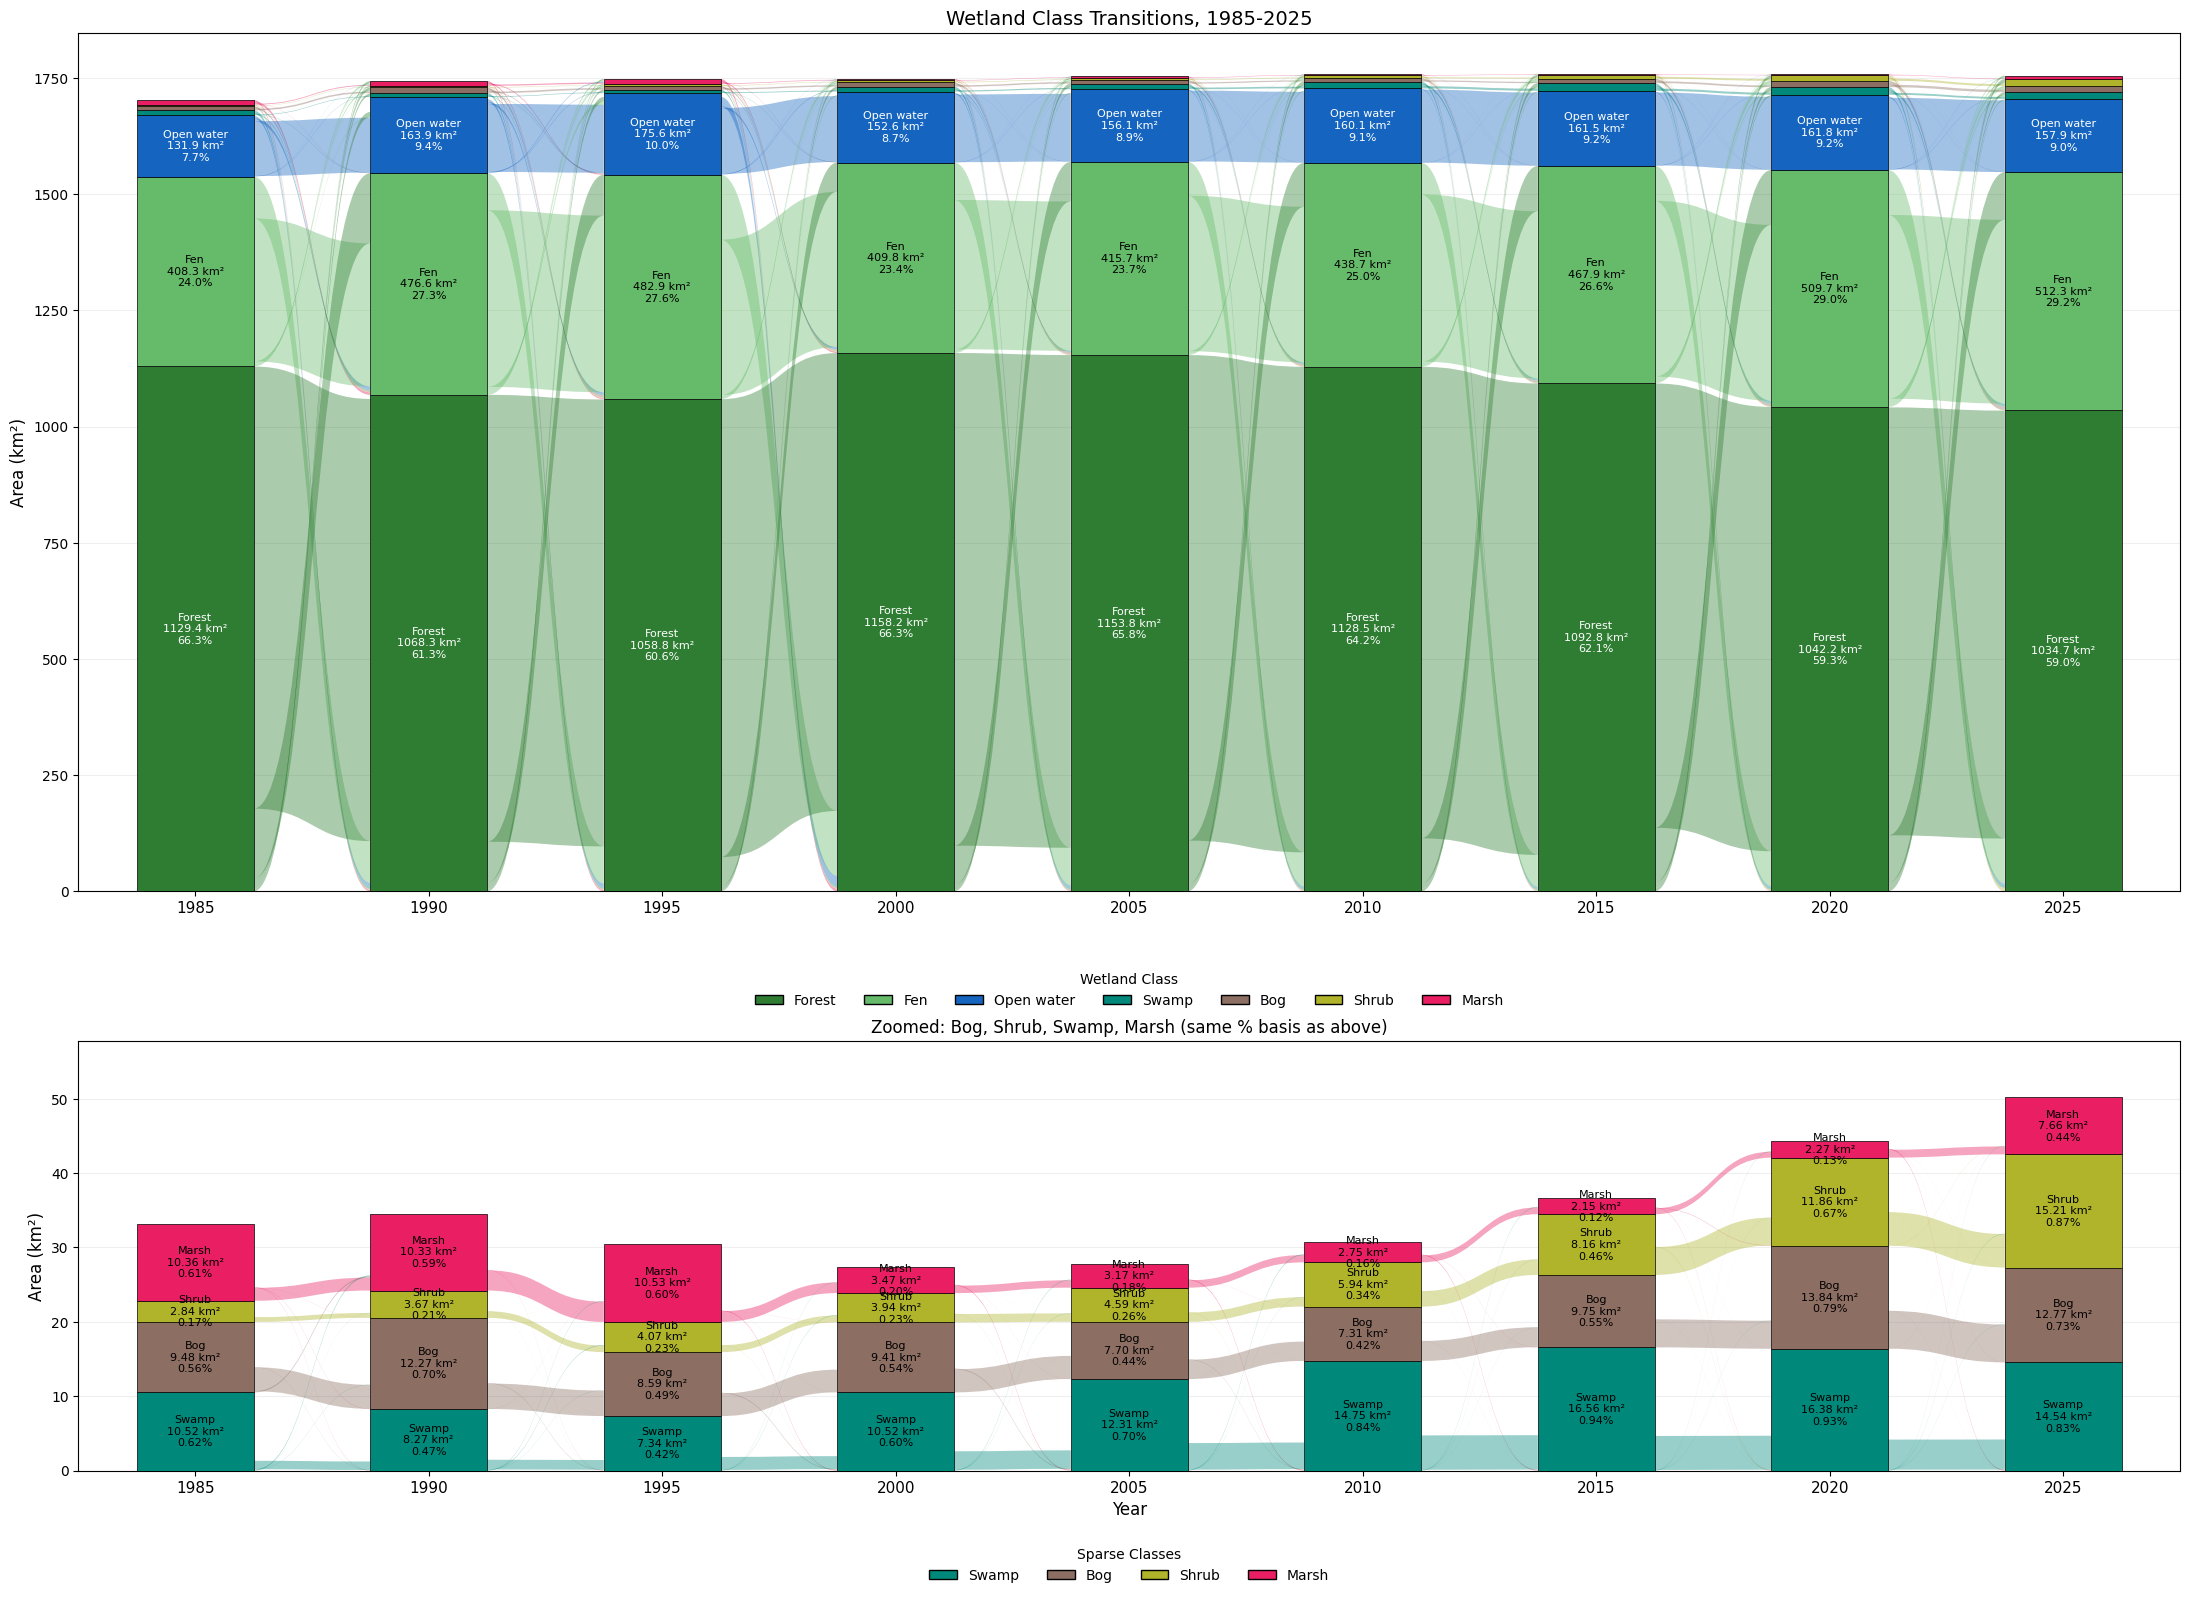

In [24]:
# ============================================
# Combined 7-class alluvial diagram — main chart + zoomed sparse-class panel
# ============================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.path import Path
import matplotlib.patches as mpatches

class_colors_7 = {
    0: '#8D6E63',  # Bog
    1: '#66BB6A',  # Fen
    2: '#2E7D32',  # Forest
    3: '#E91E63',  # Marsh
    4: '#1565C0',  # Open water
    5: '#AFB42B',  # Shrub
    6: '#00897B',  # Swamp
}

fig, (ax_main, ax_sparse) = plt.subplots(
    2, 1, figsize=(22, 16),
    gridspec_kw={'height_ratios': [2, 1]}  # main panel taller than sparse panel
)

bar_width = 0.5
x_positions = np.arange(len(ALL_YEARS_7CLASS))

# ----------------------------------------------------------------------------
# PANEL 1 (top): Main chart, all 7 classes, full scale
# ----------------------------------------------------------------------------
stack_order_7 = [2, 1, 4, 6, 0, 5, 3]  # Forest, Fen, Open water, Swamp, Bog, Shrub, Marsh
stratum_bounds_7 = {}

for i, xc in enumerate(x_positions):
    y_cursor = 0.0
    for c in stack_order_7:
        h = totals_7class[i, c]
        if h > 0:
            ax_main.add_patch(Rectangle(
                (xc - bar_width / 2, y_cursor), bar_width, h,
                facecolor=class_colors_7[c], edgecolor='black', linewidth=0.5, zorder=3
            ))
            pct = 100 * h / totals_7class[i].sum()
            if pct > 1.5:
                ax_main.text(xc, y_cursor + h / 2,
                        f'{CLASS_NAMES_7[c]}\n{h:.1f} km\u00b2\n{pct:.1f}%',
                        ha='center', va='center', fontsize=8, color='white' if c in [2, 4, 6] else 'black',
                        zorder=4)
            stratum_bounds_7[(i, c)] = (y_cursor, y_cursor + h)
        else:
            stratum_bounds_7[(i, c)] = (y_cursor, y_cursor)
        y_cursor += h

for i, T in enumerate(transitions_7class):
    x_a = x_positions[i] + bar_width / 2
    x_b = x_positions[i + 1] - bar_width / 2
    src_cursor = {c: stratum_bounds_7[(i, c)][0] for c in range(n_classes_7)}
    tgt_cursor = {c: stratum_bounds_7[(i + 1, c)][0] for c in range(n_classes_7)}

    for c_from in stack_order_7[::-1]:
        for c_to in stack_order_7[::-1]:
            h = T[c_from, c_to]
            if h <= 0:
                continue
            y0_a = src_cursor[c_from]; y1_a = y0_a + h; src_cursor[c_from] = y1_a
            y0_b = tgt_cursor[c_to]; y1_b = y0_b + h; tgt_cursor[c_to] = y1_b
            xm = (x_a + x_b) / 2
            verts = [(x_a, y0_a), (xm, y0_a), (xm, y0_b), (x_b, y0_b),
                     (x_b, y1_b), (xm, y1_b), (xm, y1_a), (x_a, y1_a), (x_a, y0_a)]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
            ax_main.add_patch(mpatches.PathPatch(Path(verts, codes),
                         facecolor=class_colors_7[c_from], edgecolor='none', alpha=0.4, zorder=2))

ax_main.set_xticks(x_positions)
ax_main.set_xticklabels(ALL_YEARS_7CLASS, fontsize=11)
ax_main.set_ylabel('Area (km\u00b2)', fontsize=12)
ax_main.set_title(f'Wetland Class Transitions, {ALL_YEARS_7CLASS[0]}-{ALL_YEARS_7CLASS[-1]}', fontsize=14)
ax_main.set_ylim(0, totals_7class.sum(axis=1).max() * 1.05)
ax_main.set_xlim(x_positions[0] - 0.5, x_positions[-1] + 0.5)
ax_main.grid(axis='y', alpha=0.2, zorder=1)
ax_main.set_axisbelow(True)

legend_patches_main = [mpatches.Patch(facecolor=class_colors_7[c], edgecolor='black', label=CLASS_NAMES_7[c])
                   for c in stack_order_7]
ax_main.legend(handles=legend_patches_main, loc='upper center', bbox_to_anchor=(0.5, -0.08),
          ncol=7, frameon=False, title='Wetland Class')

# ----------------------------------------------------------------------------
# PANEL 2 (bottom): Sparse classes only, zoomed in
# ----------------------------------------------------------------------------
sparse_classes = [0, 5, 6, 3]  # Bog, Shrub, Swamp, Marsh
stack_order_sparse = [6, 0, 5, 3]  # Swamp, Bog, Shrub, Marsh
stratum_bounds_sparse = {}

for i, xc in enumerate(x_positions):
    y_cursor = 0.0
    for c in stack_order_sparse:
        h = totals_7class[i, c]
        if h > 0:
            ax_sparse.add_patch(Rectangle(
                (xc - bar_width / 2, y_cursor), bar_width, h,
                facecolor=class_colors_7[c], edgecolor='black', linewidth=0.5, zorder=3
            ))
            pct = 100 * h / totals_7class[i].sum()
            ax_sparse.text(xc, y_cursor + h / 2,
                    f'{CLASS_NAMES_7[c]}\n{h:.2f} km\u00b2\n{pct:.2f}%',
                    ha='center', va='center', fontsize=8, color='black',
                    zorder=4)
            stratum_bounds_sparse[(i, c)] = (y_cursor, y_cursor + h)
        else:
            stratum_bounds_sparse[(i, c)] = (y_cursor, y_cursor)
        y_cursor += h

for i, T in enumerate(transitions_7class):
    x_a = x_positions[i] + bar_width / 2
    x_b = x_positions[i + 1] - bar_width / 2
    src_cursor = {c: stratum_bounds_sparse[(i, c)][0] for c in sparse_classes}
    tgt_cursor = {c: stratum_bounds_sparse[(i + 1, c)][0] for c in sparse_classes}

    for c_from in stack_order_sparse[::-1]:
        for c_to in stack_order_sparse[::-1]:
            h = T[c_from, c_to]
            if h <= 0:
                continue
            y0_a = src_cursor[c_from]; y1_a = y0_a + h; src_cursor[c_from] = y1_a
            y0_b = tgt_cursor[c_to]; y1_b = y0_b + h; tgt_cursor[c_to] = y1_b
            xm = (x_a + x_b) / 2
            verts = [(x_a, y0_a), (xm, y0_a), (xm, y0_b), (x_b, y0_b),
                     (x_b, y1_b), (xm, y1_b), (xm, y1_a), (x_a, y1_a), (x_a, y0_a)]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
            ax_sparse.add_patch(mpatches.PathPatch(Path(verts, codes),
                         facecolor=class_colors_7[c_from], edgecolor='none', alpha=0.4, zorder=2))

ax_sparse.set_xticks(x_positions)
ax_sparse.set_xticklabels(ALL_YEARS_7CLASS, fontsize=11)
ax_sparse.set_ylabel('Area (km\u00b2)', fontsize=12)
ax_sparse.set_xlabel('Year', fontsize=12)
ax_sparse.set_title('Zoomed: Bog, Shrub, Swamp, Marsh (same % basis as above)', fontsize=12)

sparse_max = max(totals_7class[i, sparse_classes].sum() for i in range(len(ALL_YEARS_7CLASS)))
ax_sparse.set_ylim(0, sparse_max * 1.15)
ax_sparse.set_xlim(x_positions[0] - 0.5, x_positions[-1] + 0.5)
ax_sparse.grid(axis='y', alpha=0.2, zorder=1)
ax_sparse.set_axisbelow(True)

legend_patches_sparse = [mpatches.Patch(facecolor=class_colors_7[c], edgecolor='black', label=CLASS_NAMES_7[c])
                          for c in stack_order_sparse]
ax_sparse.legend(handles=legend_patches_sparse, loc='upper center', bbox_to_anchor=(0.5, -0.15),
           ncol=4, frameon=False, title='Sparse Classes')

plt.tight_layout()
plt.savefig('/content/wetland_7class_combined.png', dpi=200, bbox_inches='tight')
plt.show()

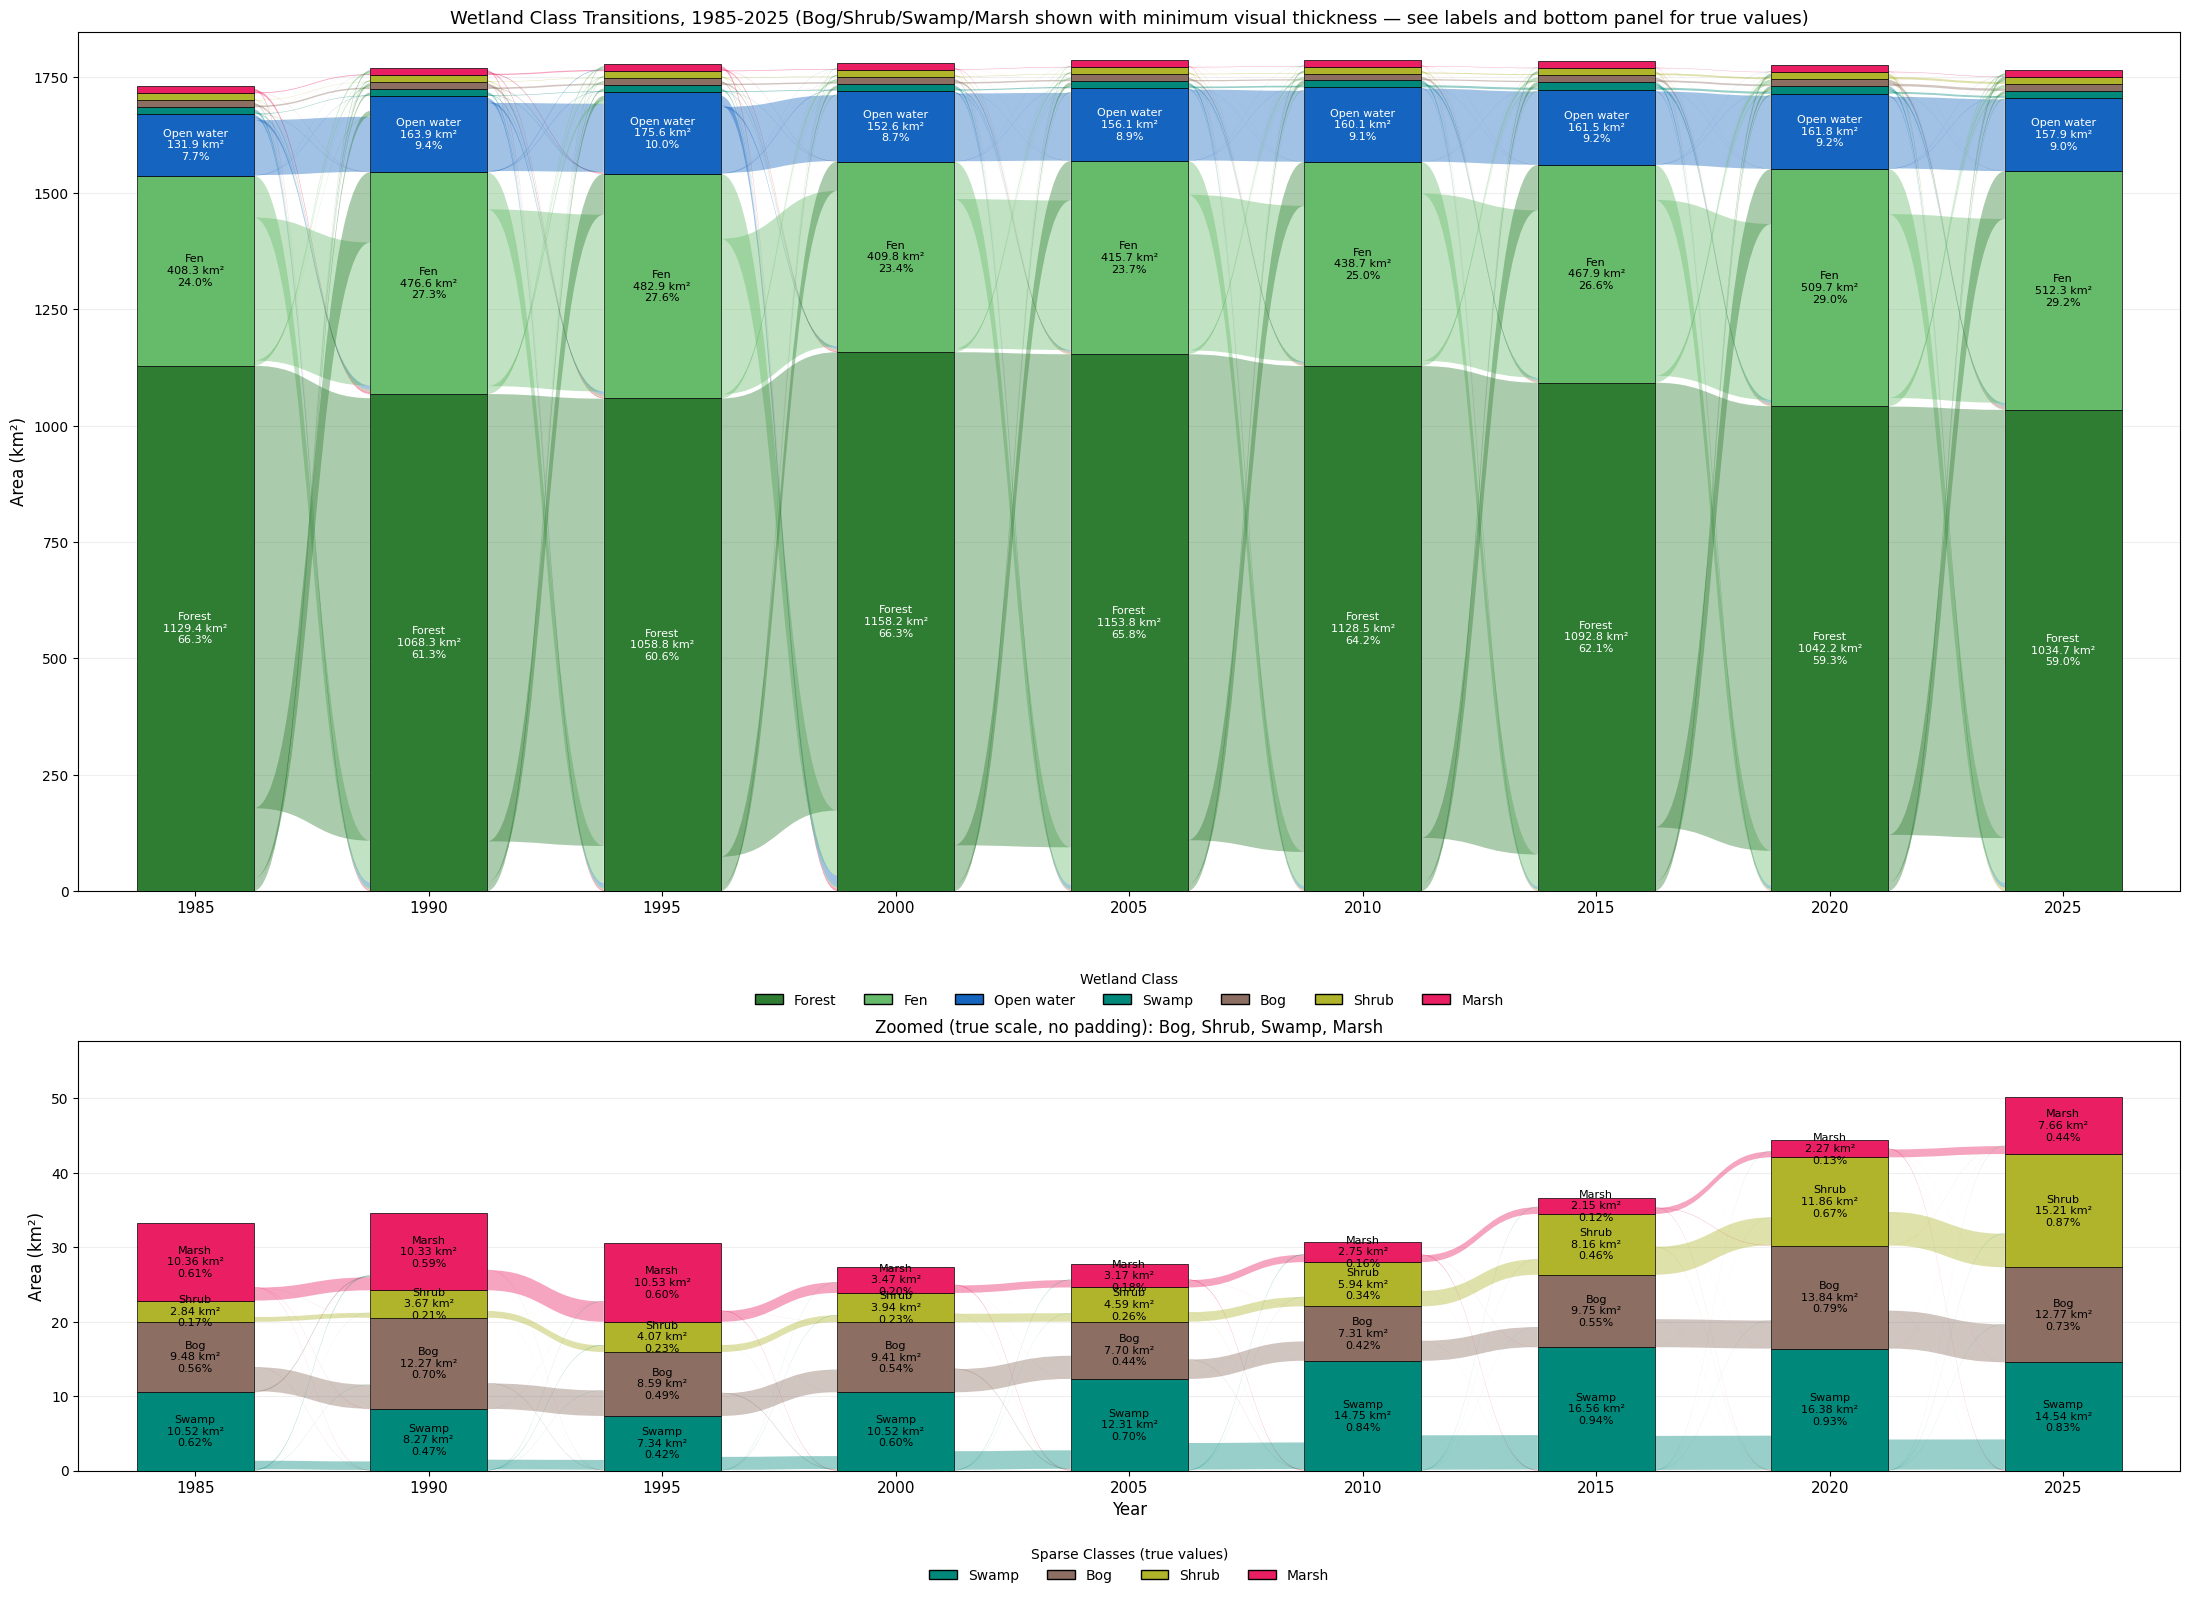

In [25]:
# ============================================
# Combined 7-class alluvial diagram — main chart + zoomed sparse-class panel
# Main panel uses a minimum visual bar height so tiny classes (Marsh, etc.)
# remain visible as a colored band; the printed label always shows the
# TRUE area/percentage, not the padded visual height. The bottom panel
# shows the sparse classes at their true, unpadded scale for an accurate
# read of their actual magnitude and trend.
# ============================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.path import Path
import matplotlib.patches as mpatches

class_colors_7 = {
    0: '#8D6E63',  # Bog
    1: '#66BB6A',  # Fen
    2: '#2E7D32',  # Forest
    3: '#E91E63',  # Marsh
    4: '#1565C0',  # Open water
    5: '#AFB42B',  # Shrub
    6: '#00897B',  # Swamp
}

fig, (ax_main, ax_sparse) = plt.subplots(
    2, 1, figsize=(22, 16),
    gridspec_kw={'height_ratios': [2, 1]}
)

bar_width = 0.5
x_positions = np.arange(len(ALL_YEARS_7CLASS))

# ----------------------------------------------------------------------------
# PANEL 1 (top): Main chart, all 7 classes, with minimum visual bar height
# ----------------------------------------------------------------------------
stack_order_7 = [2, 1, 4, 6, 0, 5, 3]  # Forest, Fen, Open water, Swamp, Bog, Shrub, Marsh
stratum_bounds_7 = {}

MIN_VISUAL_HEIGHT = 15  # km², artificial minimum just for rendering visibility

for i, xc in enumerate(x_positions):
    y_cursor = 0.0
    for c in stack_order_7:
        h_real = totals_7class[i, c]
        h_draw = max(h_real, MIN_VISUAL_HEIGHT) if h_real > 0 else 0
        if h_draw > 0:
            ax_main.add_patch(Rectangle(
                (xc - bar_width / 2, y_cursor), bar_width, h_draw,
                facecolor=class_colors_7[c], edgecolor='black', linewidth=0.5, zorder=3
            ))
            pct = 100 * h_real / totals_7class[i].sum()
            if pct > 1.5:
                ax_main.text(xc, y_cursor + h_draw / 2,
                        f'{CLASS_NAMES_7[c]}\n{h_real:.1f} km\u00b2\n{pct:.1f}%',
                        ha='center', va='center', fontsize=8, color='white' if c in [2, 4, 6] else 'black',
                        zorder=4)
            stratum_bounds_7[(i, c)] = (y_cursor, y_cursor + h_draw)
        else:
            stratum_bounds_7[(i, c)] = (y_cursor, y_cursor)
        y_cursor += h_draw

for i, T in enumerate(transitions_7class):
    x_a = x_positions[i] + bar_width / 2
    x_b = x_positions[i + 1] - bar_width / 2
    src_cursor = {c: stratum_bounds_7[(i, c)][0] for c in range(n_classes_7)}
    tgt_cursor = {c: stratum_bounds_7[(i + 1, c)][0] for c in range(n_classes_7)}

    for c_from in stack_order_7[::-1]:
        for c_to in stack_order_7[::-1]:
            h = T[c_from, c_to]
            if h <= 0:
                continue
            y0_a = src_cursor[c_from]; y1_a = y0_a + h; src_cursor[c_from] = y1_a
            y0_b = tgt_cursor[c_to]; y1_b = y0_b + h; tgt_cursor[c_to] = y1_b
            xm = (x_a + x_b) / 2
            verts = [(x_a, y0_a), (xm, y0_a), (xm, y0_b), (x_b, y0_b),
                     (x_b, y1_b), (xm, y1_b), (xm, y1_a), (x_a, y1_a), (x_a, y0_a)]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
            ax_main.add_patch(mpatches.PathPatch(Path(verts, codes),
                         facecolor=class_colors_7[c_from], edgecolor='none', alpha=0.4, zorder=2))

ax_main.set_xticks(x_positions)
ax_main.set_xticklabels(ALL_YEARS_7CLASS, fontsize=11)
ax_main.set_ylabel('Area (km\u00b2)', fontsize=12)
ax_main.set_title(f'Wetland Class Transitions, {ALL_YEARS_7CLASS[0]}-{ALL_YEARS_7CLASS[-1]}'
                   ' (Bog/Shrub/Swamp/Marsh shown with minimum visual thickness \u2014'
                   ' see labels and bottom panel for true values)', fontsize=13)
ax_main.set_ylim(0, totals_7class.sum(axis=1).max() * 1.05)
ax_main.set_xlim(x_positions[0] - 0.5, x_positions[-1] + 0.5)
ax_main.grid(axis='y', alpha=0.2, zorder=1)
ax_main.set_axisbelow(True)

legend_patches_main = [mpatches.Patch(facecolor=class_colors_7[c], edgecolor='black', label=CLASS_NAMES_7[c])
                   for c in stack_order_7]
ax_main.legend(handles=legend_patches_main, loc='upper center', bbox_to_anchor=(0.5, -0.08),
          ncol=7, frameon=False, title='Wetland Class')

# ----------------------------------------------------------------------------
# PANEL 2 (bottom): Sparse classes only, TRUE scale (no padding), zoomed in
# ----------------------------------------------------------------------------
sparse_classes = [0, 5, 6, 3]  # Bog, Shrub, Swamp, Marsh
stack_order_sparse = [6, 0, 5, 3]  # Swamp, Bog, Shrub, Marsh
stratum_bounds_sparse = {}

for i, xc in enumerate(x_positions):
    y_cursor = 0.0
    for c in stack_order_sparse:
        h = totals_7class[i, c]
        if h > 0:
            ax_sparse.add_patch(Rectangle(
                (xc - bar_width / 2, y_cursor), bar_width, h,
                facecolor=class_colors_7[c], edgecolor='black', linewidth=0.5, zorder=3
            ))
            pct = 100 * h / totals_7class[i].sum()
            ax_sparse.text(xc, y_cursor + h / 2,
                    f'{CLASS_NAMES_7[c]}\n{h:.2f} km\u00b2\n{pct:.2f}%',
                    ha='center', va='center', fontsize=8, color='black',
                    zorder=4)
            stratum_bounds_sparse[(i, c)] = (y_cursor, y_cursor + h)
        else:
            stratum_bounds_sparse[(i, c)] = (y_cursor, y_cursor)
        y_cursor += h

for i, T in enumerate(transitions_7class):
    x_a = x_positions[i] + bar_width / 2
    x_b = x_positions[i + 1] - bar_width / 2
    src_cursor = {c: stratum_bounds_sparse[(i, c)][0] for c in sparse_classes}
    tgt_cursor = {c: stratum_bounds_sparse[(i + 1, c)][0] for c in sparse_classes}

    for c_from in stack_order_sparse[::-1]:
        for c_to in stack_order_sparse[::-1]:
            h = T[c_from, c_to]
            if h <= 0:
                continue
            y0_a = src_cursor[c_from]; y1_a = y0_a + h; src_cursor[c_from] = y1_a
            y0_b = tgt_cursor[c_to]; y1_b = y0_b + h; tgt_cursor[c_to] = y1_b
            xm = (x_a + x_b) / 2
            verts = [(x_a, y0_a), (xm, y0_a), (xm, y0_b), (x_b, y0_b),
                     (x_b, y1_b), (xm, y1_b), (xm, y1_a), (x_a, y1_a), (x_a, y0_a)]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
            ax_sparse.add_patch(mpatches.PathPatch(Path(verts, codes),
                         facecolor=class_colors_7[c_from], edgecolor='none', alpha=0.4, zorder=2))

ax_sparse.set_xticks(x_positions)
ax_sparse.set_xticklabels(ALL_YEARS_7CLASS, fontsize=11)
ax_sparse.set_ylabel('Area (km\u00b2)', fontsize=12)
ax_sparse.set_xlabel('Year', fontsize=12)
ax_sparse.set_title('Zoomed (true scale, no padding): Bog, Shrub, Swamp, Marsh', fontsize=12)

sparse_max = max(totals_7class[i, sparse_classes].sum() for i in range(len(ALL_YEARS_7CLASS)))
ax_sparse.set_ylim(0, sparse_max * 1.15)
ax_sparse.set_xlim(x_positions[0] - 0.5, x_positions[-1] + 0.5)
ax_sparse.grid(axis='y', alpha=0.2, zorder=1)
ax_sparse.set_axisbelow(True)

legend_patches_sparse = [mpatches.Patch(facecolor=class_colors_7[c], edgecolor='black', label=CLASS_NAMES_7[c])
                          for c in stack_order_sparse]
ax_sparse.legend(handles=legend_patches_sparse, loc='upper center', bbox_to_anchor=(0.5, -0.15),
           ncol=4, frameon=False, title='Sparse Classes (true values)')

plt.tight_layout()
plt.savefig('/content/wetland_7class_combined.png', dpi=200, bbox_inches='tight')
plt.show()

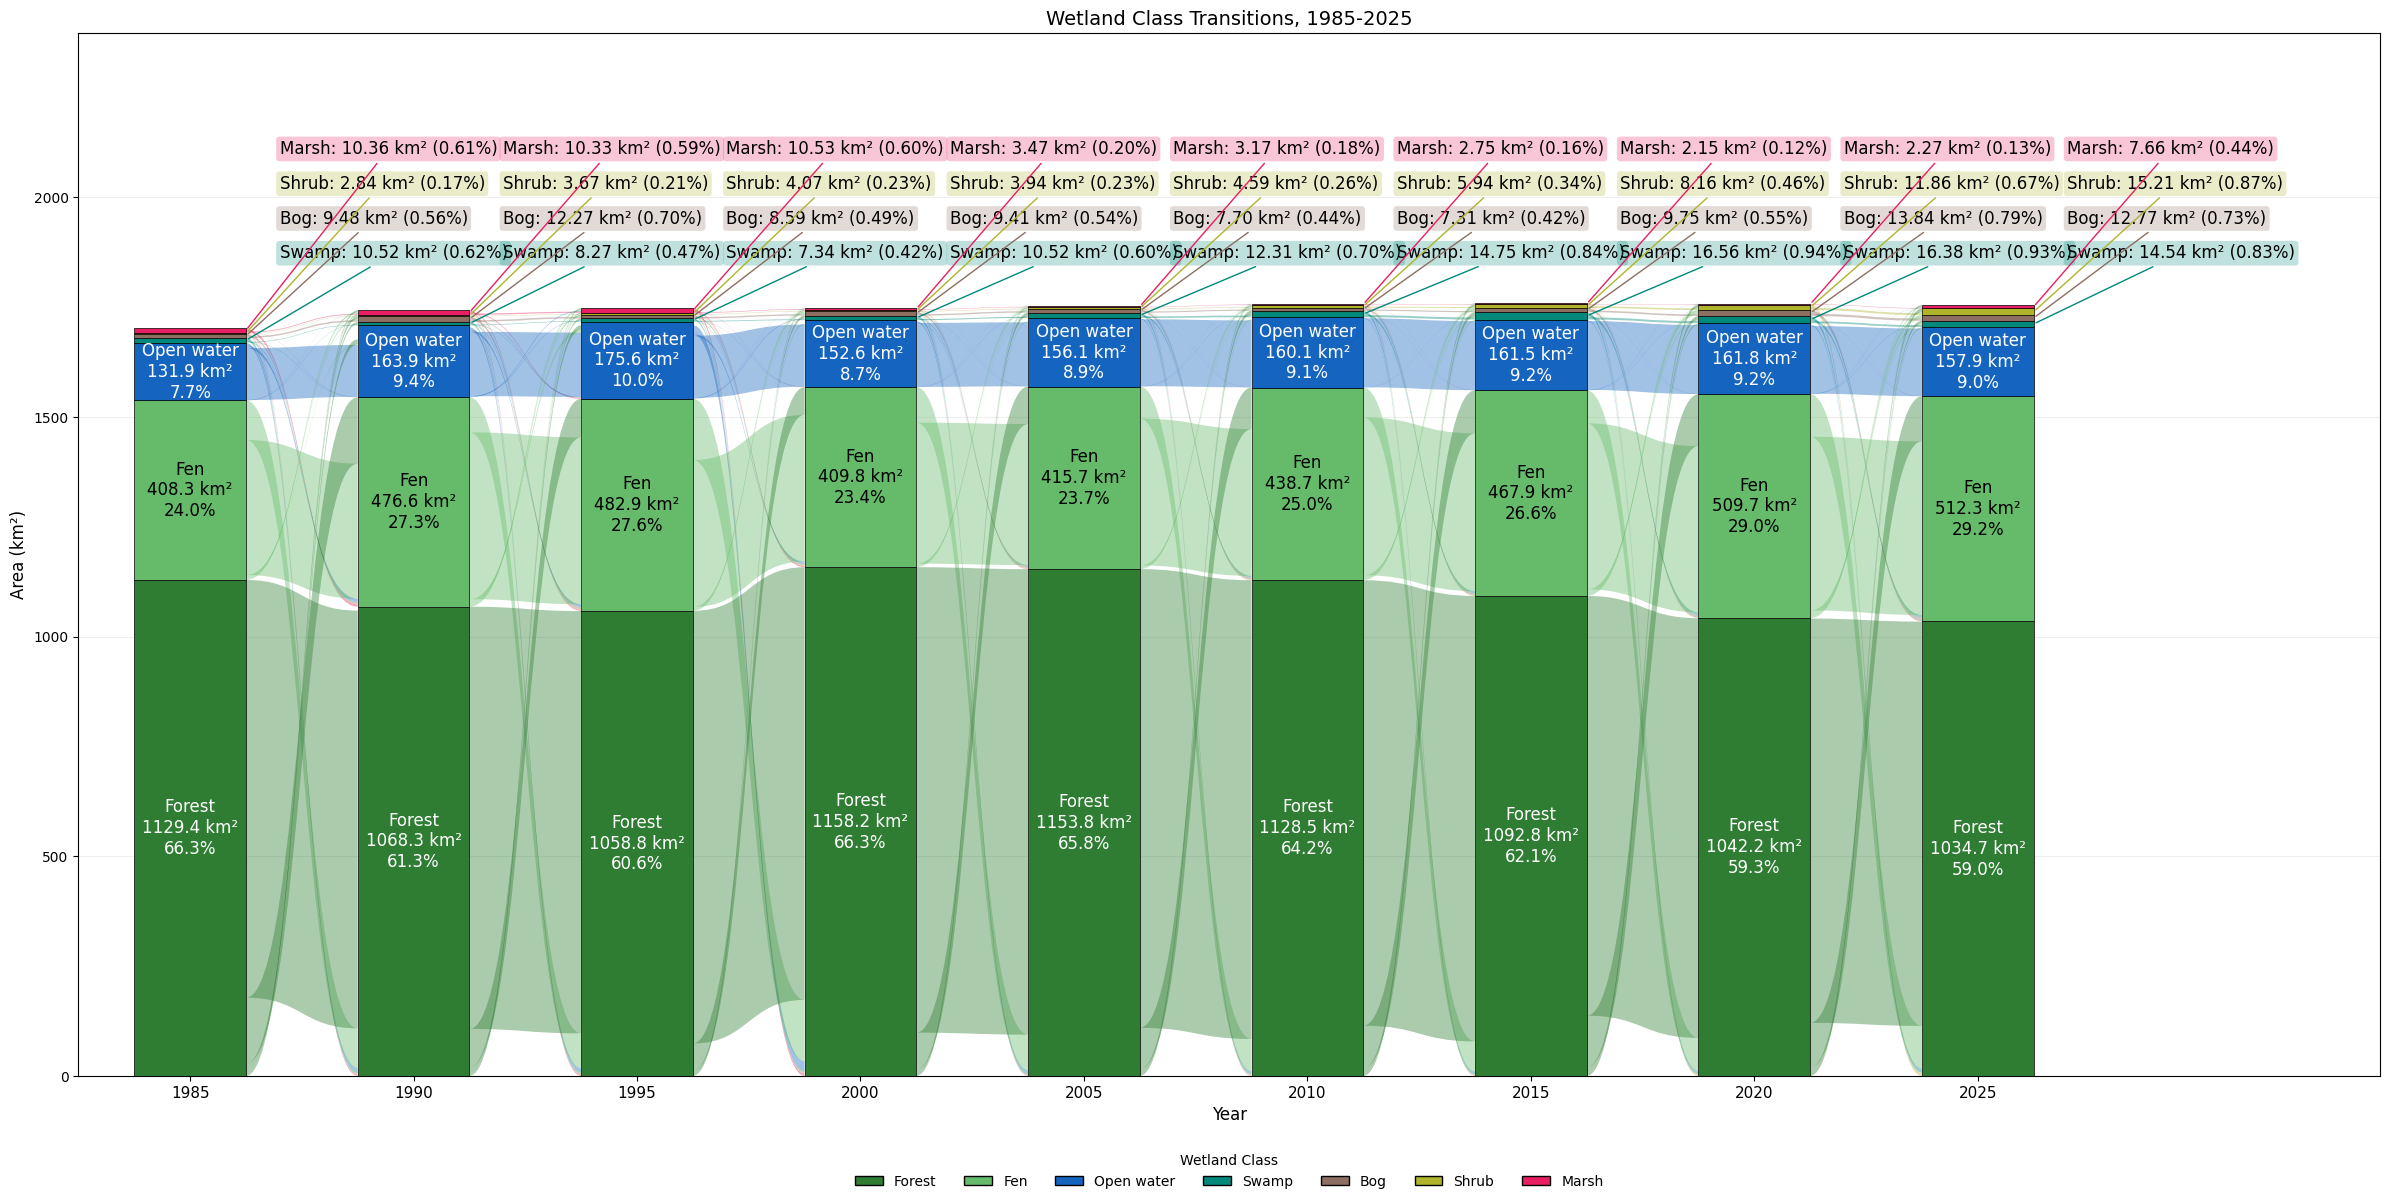

In [31]:
# ============================================
# Single combined chart — all 7 classes in ONE stack, with callout
# labels (leader lines) for segments too thin to hold text directly
# ============================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.path import Path
import matplotlib.patches as mpatches

class_colors_7 = {
    0: '#8D6E63', 1: '#66BB6A', 2: '#2E7D32', 3: '#E91E63',
    4: '#1565C0', 5: '#AFB42B', 6: '#00897B',
}

fig, ax = plt.subplots(figsize=(24, 12))
bar_width = 0.5
x_positions = np.arange(len(ALL_YEARS_7CLASS))

stack_order_7 = [2, 1, 4, 6, 0, 5, 3]  # Forest, Fen, Open water, Swamp, Bog, Shrub, Marsh
stratum_bounds_7 = {}

LABEL_THRESHOLD_PCT = 1.5  # below this, use a callout instead of inline text

for i, xc in enumerate(x_positions):
    y_cursor = 0.0
    for c in stack_order_7:
        h = totals_7class[i, c]
        if h > 0:
            ax.add_patch(Rectangle(
                (xc - bar_width / 2, y_cursor), bar_width, h,
                facecolor=class_colors_7[c], edgecolor='black', linewidth=0.5, zorder=3
            ))
            stratum_bounds_7[(i, c)] = (y_cursor, y_cursor + h)
        else:
            stratum_bounds_7[(i, c)] = (y_cursor, y_cursor)
        y_cursor += h

# Draw flows (unchanged)
for i, T in enumerate(transitions_7class):
    x_a = x_positions[i] + bar_width / 2
    x_b = x_positions[i + 1] - bar_width / 2
    src_cursor = {c: stratum_bounds_7[(i, c)][0] for c in range(n_classes_7)}
    tgt_cursor = {c: stratum_bounds_7[(i + 1, c)][0] for c in range(n_classes_7)}
    for c_from in stack_order_7[::-1]:
        for c_to in stack_order_7[::-1]:
            h = T[c_from, c_to]
            if h <= 0:
                continue
            y0_a = src_cursor[c_from]; y1_a = y0_a + h; src_cursor[c_from] = y1_a
            y0_b = tgt_cursor[c_to]; y1_b = y0_b + h; tgt_cursor[c_to] = y1_b
            xm = (x_a + x_b) / 2
            verts = [(x_a, y0_a), (xm, y0_a), (xm, y0_b), (x_b, y0_b),
                     (x_b, y1_b), (xm, y1_b), (xm, y1_a), (x_a, y1_a), (x_a, y0_a)]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
            ax.add_patch(mpatches.PathPatch(Path(verts, codes),
                         facecolor=class_colors_7[c_from], edgecolor='none', alpha=0.4, zorder=2))

# ----------------------------------------------------------------------------
# NOW add labels — inline for large segments, callouts (leader lines) for thin ones
# ----------------------------------------------------------------------------
total_max = totals_7class.sum(axis=1).max()

for i, xc in enumerate(x_positions):
    # Track how many callouts already placed for this bar, to stack them outward
    callout_offset = 0
    for c in stack_order_7:
        h = totals_7class[i, c]
        if h <= 0:
            continue
        y0, y1 = stratum_bounds_7[(i, c)]
        y_mid = (y0 + y1) / 2
        pct = 100 * h / totals_7class[i].sum()

        if pct > LABEL_THRESHOLD_PCT:
            # Big enough — label directly inside the segment
            ax.text(xc, y_mid, f'{CLASS_NAMES_7[c]}\n{h:.1f} km\u00b2\n{pct:.1f}%',
                    ha='center', va='center', fontsize=12,
                    color='white' if c in [2, 4, 6] else 'black', zorder=5)
        else:
            # Too thin — draw a callout to the right of the bar with a leader line
            callout_offset += 1
            label_y = total_max * 1.02 + callout_offset * (total_max * 0.045)
            label_x = xc + bar_width / 2 + 0.15

            ax.annotate(
                f'{CLASS_NAMES_7[c]}: {h:.2f} km\u00b2 ({pct:.2f}%)',
                xy=(xc + bar_width / 2, y_mid),         # point of the sliver
                xytext=(label_x, label_y),                # where the text sits
                fontsize=12, color='black',
                arrowprops=dict(arrowstyle='-', color=class_colors_7[c], lw=1),
                ha='left', va='center', zorder=6,
                bbox=dict(boxstyle='round,pad=0.2', facecolor=class_colors_7[c], alpha=0.25, edgecolor='none')
            )

ax.set_xticks(x_positions)
ax.set_xticklabels(ALL_YEARS_7CLASS, fontsize=11)
ax.set_ylabel('Area (km\u00b2)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_title(f'Wetland Class Transitions, {ALL_YEARS_7CLASS[0]}-{ALL_YEARS_7CLASS[-1]}', fontsize=14)
ax.set_ylim(0, total_max * 1.35)  # extra headroom for callouts above the bars
ax.set_xlim(x_positions[0] - 0.5, x_positions[-1] + 1.8)  # extra room on the right for callout text
ax.grid(axis='y', alpha=0.2, zorder=1)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(facecolor=class_colors_7[c], edgecolor='black', label=CLASS_NAMES_7[c])
                   for c in stack_order_7]
ax.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.12),
          ncol=7, frameon=False, title='Wetland Class')

plt.tight_layout()
plt.savefig('/content/wetland_7class_callouts.png', dpi=200, bbox_inches='tight')
plt.show()

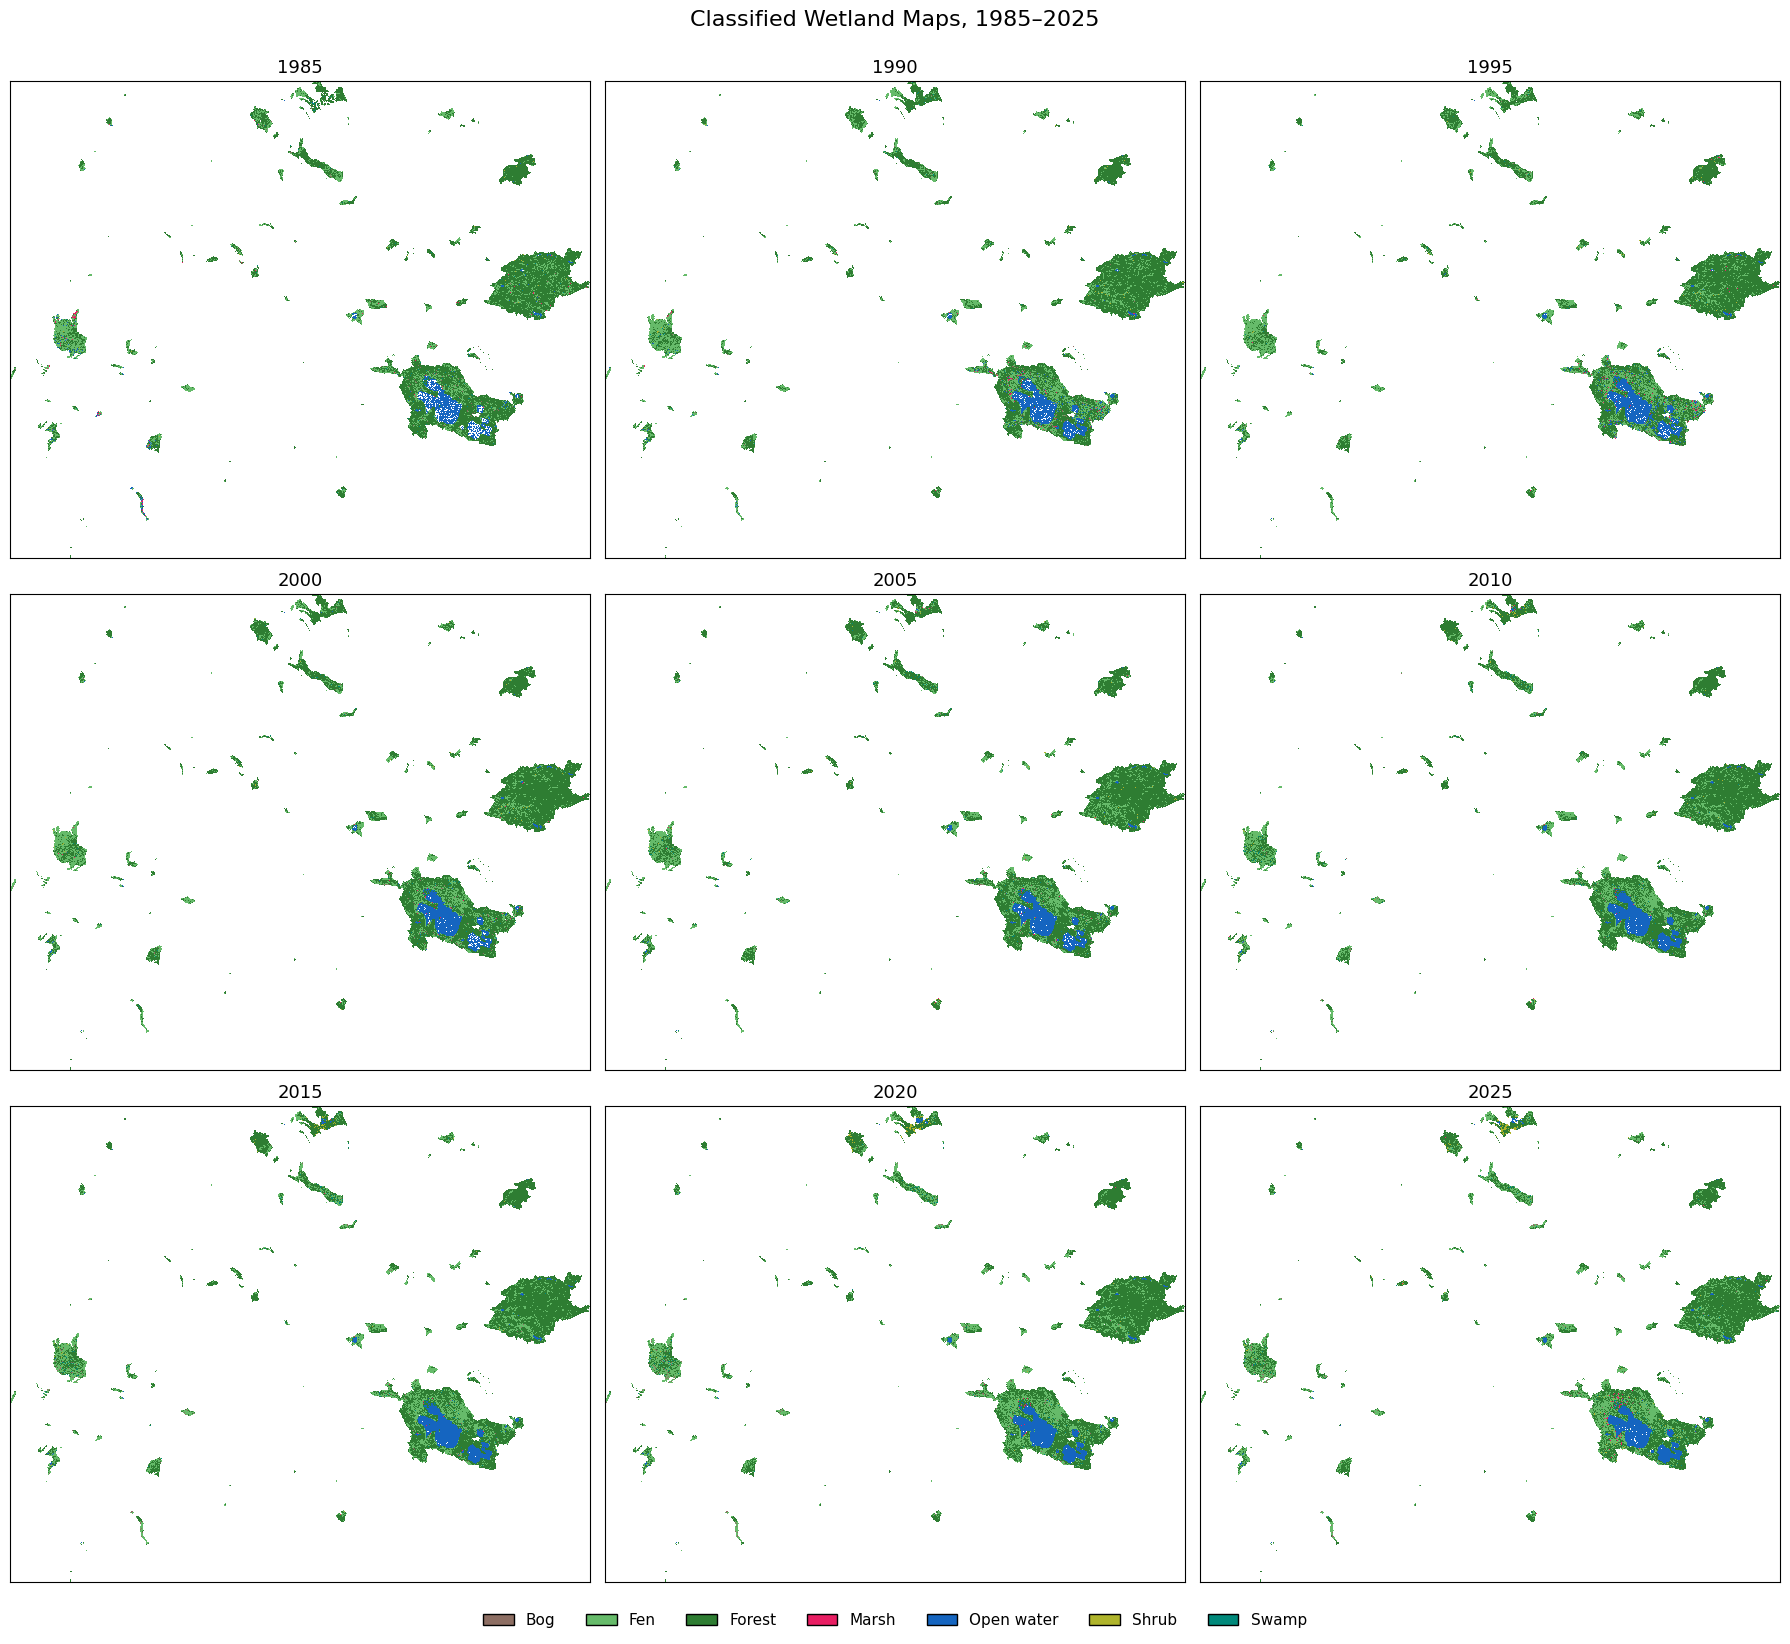

In [27]:
# ============================================
# Display classified maps for all 9 years, same colors as the alluvial chart
# ============================================

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

class_colors_7 = {
    0: '#8D6E63',  # Bog
    1: '#66BB6A',  # Fen
    2: '#2E7D32',  # Forest
    3: '#E91E63',  # Marsh
    4: '#1565C0',  # Open water
    5: '#AFB42B',  # Shrub
    6: '#00897B',  # Swamp
}

# Build a colormap in class order 0-6
cmap_colors = [class_colors_7[c] for c in range(7)]
cmap = ListedColormap(cmap_colors)
cmap.set_bad('white')  # NoData renders white
norm = BoundaryNorm([-0.5 + i for i in range(8)], cmap.N)

fig, axes = plt.subplots(3, 3, figsize=(18, 16))

for ax, year in zip(axes.flat, ALL_YEARS_7CLASS):
    arr = classified_arrays_7class[year].astype(float)
    arr_masked = np.where(watershed_mask_7class, arr, np.nan)  # only show inside watershed
    arr_masked[arr_masked == -1] = np.nan  # also hide any remaining NoData within the mask

    ax.imshow(arr_masked, cmap=cmap, norm=norm, interpolation='nearest')
    ax.set_title(str(year), fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Classified Wetland Maps, 1985\u20132025', fontsize=16, y=1.0)

# Shared legend below all subplots
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(facecolor=class_colors_7[c], edgecolor='black', label=CLASS_NAMES_7[c])
                   for c in range(7)]
fig.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=7, frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig('/content/classified_maps_all_years.png', dpi=200, bbox_inches='tight')
plt.show()